# Architecture-Dependent Image Enhancement and Validation-Weighted Deep Ensemble Learning for Endoscopic Image Classification

**Google Colab notebook accompanying the manuscript of the same title.**

This notebook evaluates four matched image representations—**raw, sharpened, CLAHE, and
gamma correction**—across **ResNet50, EfficientNet-B0, and ConvNeXt-Tiny**. The complete
3 × 4 factorial comparison is the primary experiment.

One configuration is selected independently for each backbone using validation macro-F1.
The selected probability vectors are then combined through a **validation-weighted
multi-enhancement ensemble**. Component selection and fusion-weight optimization use only
the validation set; the held-out test set is used once for final evaluation.

The original-image ZIP is read from Google Drive, copied to Colab local storage, and
extracted there for faster training. Checkpoints and research outputs remain in Drive.

### Reproducibility notes

- **Data:** GastroEndoNet v3 (Bitto et al., 2025), https://data.mendeley.com/datasets/ffyn828yf4/3.
  The original-image ZIP must contain the four class folders (`GERD`, `GERD Normal`, `Polyp`,
  `Polyp Normal`) at its root and be placed at `DRIVE_ZIP_PATH` (see the configuration cell).
- **Run settings of the saved outputs:** `FAST_RUN = False`, seed 42, Google Colab NVIDIA T4 GPU.
  Run the cells in order; `RESUME_COMPLETED_EXPERIMENTS = True` lets an interrupted run continue.
- **Main results in the saved outputs:** selected components ResNet50 + sharpening,
  EfficientNet-B0 + CLAHE and ConvNeXt-Tiny + CLAHE; fusion weights 0.30 / 0.25 / 0.45
  (validation macro-F1 0.9039); test accuracy 0.8918 and macro-F1 0.8935; exact McNemar
  p = 0.0192 against the validation-selected individual configuration.
- **Timing:** latency and training-time columns depend on the runtime and vary between runs.
  Training time is recorded as 0 for experiments that were resumed from saved results.
  Classification metrics may differ slightly on other hardware or library versions.


In [ ]:
# ============================================================
# 0. Main configuration: edit this cell only
# ============================================================

FAST_RUN = False          # True: pipeline check; False: manuscript experiment
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15
FAST_EPOCHS = 2
PATIENCE = 4
FREEZE_EPOCHS = 2
NUM_WORKERS = 2
LABEL_SMOOTHING = 0.05
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
VAL_SIZE = 0.15
TEST_SIZE = 0.15
USE_PRETRAINED = True
STRICT_PRIMARY_CHECK = True
KEEP_ALL_CHECKPOINTS = False
RESUME_COMPLETED_EXPERIMENTS = True
ENSEMBLE_WEIGHT_STEP = 0.05

BACKBONE_MODELS = ["resnet50", "efficientnet_b0", "convnext_tiny"]
SINGLE_VIEW_MODES = ["raw", "sharpen", "clahe", "gamma"]
ENHANCEMENT_MODES = SINGLE_VIEW_MODES

# FAST_RUN preserves the complete code path but uses fewer images and epochs.
FAST_TRAIN_PER_CLASS = 220
FAST_VAL_PER_CLASS = 70
FAST_TEST_PER_CLASS = 70

DRIVE_ZIP_PATH = "/content/drive/MyDrive/Dataset/GERD_Polyp/Gerd_Polyp_Original.zip"
DRIVE_PROJECT_ROOT = "/content/drive/MyDrive/GERD_POLYP_COLAB"
LOCAL_ZIP_PATH = "/content/Gerd_Polyp_Originial.zip"
LOCAL_DATASET_ROOT = "/content/gerd_polyp_original"
EXPECTED_PRIMARY_TOTAL = 4006
EXPECTED_CLASS_COUNTS = {
    "GERD": 974,
    "GERD Normal": 1103,
    "Polyp": 779,
    "Polyp Normal": 1150,
}


## 1. Research Design

The primary study uses a balanced factorial design. ResNet50, EfficientNet-B0, and
ConvNeXt-Tiny are each trained separately on raw, sharpened, CLAHE, and gamma-corrected
images under an identical split and training protocol. The proposed validation-weighted
ensemble is constructed only after validation-based component selection and does not alter
the 12 primary single-view experiments.


In [ ]:
from IPython.display import display, Markdown
import pandas as pd

research_design = pd.DataFrame({
    "Component": [
        "Research question", "Primary dataset", "Classes", "Primary experiment",
        "Proposed ensemble", "Trained model count",
        "Statistical analysis", "Research scope"
    ],
    "Design": [
        "How do image enhancements interact with deep backbones, and can validation-weighted fusion exploit the resulting diversity?",
        "GastroEndoNet v3 original images only (expected n=4,006 before deduplication)",
        "GERD; GERD Normal; Polyp; Polyp Normal",
        "3 backbones × raw, sharpened, CLAHE, and gamma = 12 trained models",
        "Validation-weighted soft voting from one validation-selected configuration per backbone",
        "12 independently trained single-view models; probability fusion requires no retraining",
        "Bootstrap confidence intervals and one prespecified exact paired McNemar test",
        "Computational evaluation of architecture–enhancement interaction",
    ],
})
display(research_design)

if FAST_RUN:
    display(Markdown(
        "> **FAST_RUN is active.** These outputs verify code only. Set `FAST_RUN = False` "
        "and rerun all cells before reporting manuscript results."
    ))


,Component,Design
0,Research question,How do image enhancements interact with deep b...
1,Primary dataset,GastroEndoNet v3 original images only (expecte...
2,Classes,GERD; GERD Normal; Polyp; Polyp Normal
3,Primary experiment,"3 backbones × raw, sharpened, CLAHE, and gamma..."
4,Proposed ensemble,Validation-weighted soft voting from one valid...
5,Trained model count,12 independently trained single-view models; p...
6,Statistical analysis,Bootstrap confidence intervals and one prespec...
7,Research scope,Computational evaluation of architecture–enhan...


## 2. Colab Environment, Reproducibility, and Persistent Output Folders

Google Drive is mounted for persistent checkpoints and outputs. Training uses the Colab
GPU and the extracted dataset in `/content`.


In [ ]:
# ============================================================
# Imports, deterministic settings, Colab Drive, and output folders
# ============================================================
import os
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import sys
import re
import gc
import json
import time
import math
import random
import hashlib
import shutil
import warnings
from pathlib import Path
from collections import Counter

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import cv2
import scipy
from scipy.stats import binomtest

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_auc_score,
    average_precision_score, log_loss, roc_curve, precision_recall_curve,
)
from sklearn.preprocessing import label_binarize

import torch
import torchvision
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from google.colab import drive

drive.mount("/content/drive")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = DEVICE.type == "cuda"
EFFECTIVE_EPOCHS = FAST_EPOCHS if FAST_RUN else EPOCHS
BOOTSTRAP_ITERATIONS = 200 if FAST_RUN else 1000

WORK_ROOT = Path(DRIVE_PROJECT_ROOT)
RESULTS_DIR = WORK_ROOT / "results"
FIGURES_DIR = WORK_ROOT / "figures"
MODELS_DIR = WORK_ROOT / "models"
for folder in [WORK_ROOT, RESULTS_DIR, FIGURES_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

env_table = pd.DataFrame({
    "Item": [
        "Python", "PyTorch", "Torchvision", "OpenCV", "Scikit-learn",
        "Device", "FAST_RUN", "Effective epochs", "Seed", "Output root"
    ],
    "Value": [
        sys.version.split()[0], torch.__version__,
        torchvision.__version__,
        cv2.__version__, sklearn.__version__, str(DEVICE), FAST_RUN,
        EFFECTIVE_EPOCHS, SEED, str(WORK_ROOT)
    ],
})
display(env_table)

assert torch.cuda.is_available(), (
    "GPU not detected. In Colab: Runtime -> Change runtime type -> T4 GPU."
)


Mounted at /content/drive


,Item,Value
0,Python,3.13.15
1,PyTorch,2.11.0+cu128
2,Torchvision,0.26.0+cu128
3,OpenCV,5.0.0
4,Scikit-learn,1.6.1
5,Device,cuda
6,FAST_RUN,False
7,Effective epochs,15
8,Seed,42
9,Output root,/content/drive/MyDrive/GERD_POLYP_COLAB


## 3. Import the Original Dataset from Google Drive

Expected ZIP:

`MyDrive/Dataset/Gerd_Polyp/Gerd_Polyp_Original.zip`

The ZIP must contain the four class folders directly at its root: `GERD`, `GERD Normal`,
`Polyp`, and `Polyp Normal`. It is copied to `/content` and extracted locally on each new
Colab runtime. Existing complete local extraction is reused within the same runtime.


In [ ]:
# ============================================================
# Copy the Drive ZIP and extract the four original class folders locally
# ============================================================
import zipfile

drive_zip = Path(DRIVE_ZIP_PATH)
local_zip = Path(LOCAL_ZIP_PATH)
local_dataset = Path(LOCAL_DATASET_ROOT)

assert drive_zip.exists(), (
    f"Dataset ZIP was not found: {drive_zip}\n"
    "Check the exact Drive filename and path after drive.mount()."
)

expected_folder_keys = {
    "gerd", "gerd normal", "polyp", "polyp normal"
}

def normalized_folder_key(name):
    return re.sub(r"[^a-z0-9]+", " ", name.lower()).strip()

def has_four_class_folders(root):
    if not root.exists():
        return False
    present = {
        normalized_folder_key(path.name)
        for path in root.iterdir()
        if path.is_dir()
    }
    return expected_folder_keys.issubset(present)

if not has_four_class_folders(local_dataset):
    if (
        not local_zip.exists()
        or local_zip.stat().st_size != drive_zip.stat().st_size
    ):
        print("Copying dataset ZIP from Drive to Colab local storage...")
        shutil.copy2(drive_zip, local_zip)

    if local_dataset.exists():
        shutil.rmtree(local_dataset)
    local_dataset.mkdir(parents=True, exist_ok=True)

    print("Extracting the four class folders to local storage...")
    with zipfile.ZipFile(local_zip, "r") as archive:
        bad_member = archive.testzip()
        assert bad_member is None, f"Corrupted ZIP member: {bad_member}"
        archive.extractall(local_dataset)

DATASET_ROOT = local_dataset
assert has_four_class_folders(DATASET_ROOT), (
    f"The extracted ZIP does not expose the four expected class folders directly "
    f"under {DATASET_ROOT}. Found: "
    f"{[p.name for p in DATASET_ROOT.iterdir() if p.is_dir()]}"
)

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
all_image_paths = sorted(
    path for path in DATASET_ROOT.rglob("*")
    if path.is_file() and path.suffix.lower() in image_extensions
)

top_folder_records = [
    {
        "Class folder": folder.name,
        "Image files": sum(
            1 for path in folder.rglob("*")
            if path.is_file() and path.suffix.lower() in image_extensions
        ),
    }
    for folder in sorted(path for path in DATASET_ROOT.iterdir() if path.is_dir())
]
top_folders = pd.DataFrame(top_folder_records).sort_values(
    "Class folder"
).reset_index(drop=True)

display(pd.DataFrame({
    "Dataset source": [str(drive_zip)],
    "Local extraction root": [str(DATASET_ROOT)],
    "ZIP size (GB)": [drive_zip.stat().st_size / (1024 ** 3)],
    "Total image files discovered": [len(all_image_paths)],
}))
display(top_folders)

assert all_image_paths, f"No image files were found below {DATASET_ROOT}"


Copying dataset ZIP from Drive to Colab local storage...
Extracting the four class folders to local storage...


,Dataset source,Local extraction root,ZIP size (GB),Total image files discovered
0,/content/drive/MyDrive/Dataset/GERD_Polyp/Gerd...,/content/gerd_polyp_original,0.740385,4006


,Class folder,Image files
0,Gerd,974
1,Gerd Normal,1103
2,Polyp,779
3,Polyp Normal,1150


## 4. Manifest Construction and Primary-Image Verification

Labels are inferred from folder names. Primary images are identified from folder and
filename markers. The expected class counts are used as a verification target, not as
labels. When the folder structure does not expose primary images clearly, a conservative
filename-family rule is attempted. With `STRICT_PRIMARY_CHECK=True`, training will not
continue unless the selected primary set is close to the documented 4,006 images.


In [ ]:
# ============================================================
# Label inference and augmented-file recognition
# ============================================================
CLASS_NAMES = ["GERD", "GERD Normal", "Polyp", "Polyp Normal"]
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}

def normalize_text(value):
    return re.sub(r"[^a-z0-9]+", " ", str(value).lower()).strip()

def infer_label(path):
    parts = [normalize_text(part) for part in path.parts]
    for part in reversed(parts):
        if "gerd normal" in part or "normal gerd" in part:
            return "GERD Normal"
        if "polyp normal" in part or "normal polyp" in part:
            return "Polyp Normal"
    for part in reversed(parts):
        if re.search(r"\bgerd\b", part):
            return "GERD"
        if re.search(r"\bpolyp", part):
            return "Polyp"
    return None

AUGMENTATION_MARKERS = [
    "augment", "rot60", "rotate60", "rotation60", "rot90", "rotate90",
    "rotation90", "horizontal flip", "hflip", "flipped", "zoom",
    "brightness", "bright", "shear", "shifted", "transformed",
]
PRIMARY_MARKERS = ["original", "primary", "raw image", "raw dataset"]

def contains_marker(path, markers):
    text = normalize_text(str(path.relative_to(DATASET_ROOT)))
    return any(marker in text for marker in markers)

def source_family(stem):
    value = normalize_text(stem)
    tokens = value.split()
    removable = {
        "aug", "augmented", "original", "primary", "rotation", "rotate",
        "rot", "flip", "flipped", "horizontal", "hflip", "zoom",
        "brightness", "bright", "shear", "shift", "transformed",
        "60", "90", "deg", "degree",
    }
    kept = [token for token in tokens if token not in removable]
    value = " ".join(kept)
    value = re.sub(r"\s+", " ", value).strip()
    return value or normalize_text(stem)

records = []
for path in all_image_paths:
    label = infer_label(path)
    if label is None:
        continue
    records.append({
        "path": str(path),
        "relative_path": str(path.relative_to(DATASET_ROOT)),
        "label": label,
        "label_idx": CLASS_TO_IDX[label],
        "primary_hint": contains_marker(path, PRIMARY_MARKERS),
        "augmented_hint": contains_marker(path, AUGMENTATION_MARKERS),
        "source_family": f"{label}::{source_family(path.stem)}",
    })

full_manifest = pd.DataFrame(records)
assert not full_manifest.empty, (
    "Images were found, but class folders could not be mapped to the four expected labels."
)

discovery_summary = (
    full_manifest.groupby("label")
    .agg(
        total_files=("path", "size"),
        primary_hints=("primary_hint", "sum"),
        augmented_hints=("augmented_hint", "sum"),
        inferred_families=("source_family", "nunique"),
    )
    .reindex(CLASS_NAMES)
    .reset_index()
)
display(discovery_summary)


,label,total_files,primary_hints,augmented_hints,inferred_families
0,GERD,974,0,0,973
1,GERD Normal,1103,0,0,1102
2,Polyp,779,0,0,779
3,Polyp Normal,1150,0,0,1149


In [ ]:
# ============================================================
# Conservative primary-image selection
# ============================================================
def plausible_primary_count(n):
    return int(EXPECTED_PRIMARY_TOTAL * 0.85) <= n <= int(EXPECTED_PRIMARY_TOTAL * 1.15)

selection_method = None
primary_manifest = None

hinted = full_manifest[full_manifest["primary_hint"] & ~full_manifest["augmented_hint"]].copy()
non_augmented = full_manifest[~full_manifest["augmented_hint"]].copy()
family_representatives = (
    full_manifest.sort_values(["primary_hint", "augmented_hint"], ascending=[False, True])
    .drop_duplicates("source_family")
    .copy()
)

candidates = [
    ("explicit primary/original folder markers", hinted),
    ("files without augmentation markers", non_augmented),
    ("one representative per inferred source family", family_representatives),
    ("all discovered files", full_manifest),
]
for method, candidate in candidates:
    if plausible_primary_count(len(candidate)):
        primary_manifest = candidate.copy()
        selection_method = method
        break

if primary_manifest is None:
    candidate_counts = {method: len(candidate) for method, candidate in candidates}
    message = (
        "Could not verify a primary-image subset near the documented n=4,006. "
        f"Candidate counts: {candidate_counts}. Inspect discovery_summary and filenames. "
        "Do not publish results from a random split of all augmented files."
    )
    if STRICT_PRIMARY_CHECK:
        raise RuntimeError(message)
    warnings.warn(message)
    primary_manifest = full_manifest.copy()
    selection_method = "unsafe override: all files"

# Remove exact duplicate files before splitting.
def file_md5(path, chunk_size=1024 * 1024):
    digest = hashlib.md5()
    with open(path, "rb") as stream:
        while True:
            chunk = stream.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()

primary_manifest["md5"] = [file_md5(path) for path in primary_manifest["path"]]
duplicate_count = int(primary_manifest.duplicated("md5").sum())
if duplicate_count:
    primary_manifest = primary_manifest.drop_duplicates("md5").copy()

primary_manifest = primary_manifest.reset_index(drop=True)
selected_counts = (
    primary_manifest["label"].value_counts().reindex(CLASS_NAMES, fill_value=0)
    .rename_axis("Class").reset_index(name="Selected primary images")
)
selected_counts["Documented count"] = selected_counts["Class"].map(EXPECTED_CLASS_COUNTS)
selected_counts["Difference"] = (
    selected_counts["Selected primary images"] - selected_counts["Documented count"]
)

display(pd.DataFrame({
    "Selection method": [selection_method],
    "Selected images before split": [len(primary_manifest)],
    "Exact duplicates removed": [duplicate_count],
    "Documented primary total": [EXPECTED_PRIMARY_TOTAL],
}))
display(selected_counts)

if STRICT_PRIMARY_CHECK:
    assert plausible_primary_count(len(primary_manifest)), (
        "Primary-image count is outside the accepted verification range."
    )

primary_manifest.to_csv(RESULTS_DIR / "primary_image_manifest.csv", index=False)


,Selection method,Selected images before split,Exact duplicates removed,Documented primary total
0,files without augmentation markers,4004,2,4006


,Class,Selected primary images,Documented count,Difference
0,GERD,974,974,0
1,GERD Normal,1102,1103,-1
2,Polyp,779,779,0
3,Polyp Normal,1149,1150,-1


## 5. Exploratory Data Analysis

This section reports class balance, image resolution, file characteristics, and random
primary-image samples. All later experiments use the verified manifest from the previous
section.


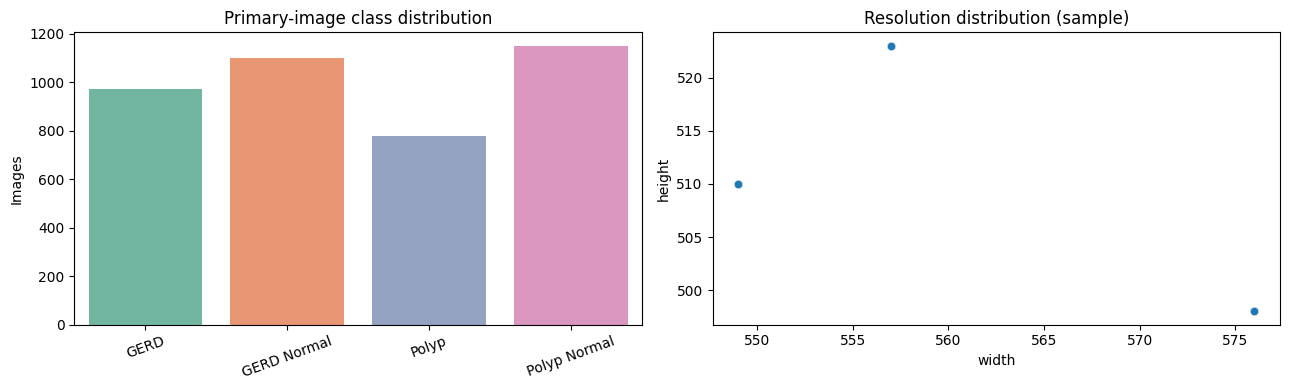

,width,height,aspect_ratio
count,500.000,500.000,500.000
mean,553.270,511.016,1.083
std,8.393,6.638,0.026
min,549.000,498.000,1.065
25%,549.000,510.000,1.076
50%,549.000,510.000,1.076
75%,557.000,510.000,1.076
max,576.000,523.000,1.157


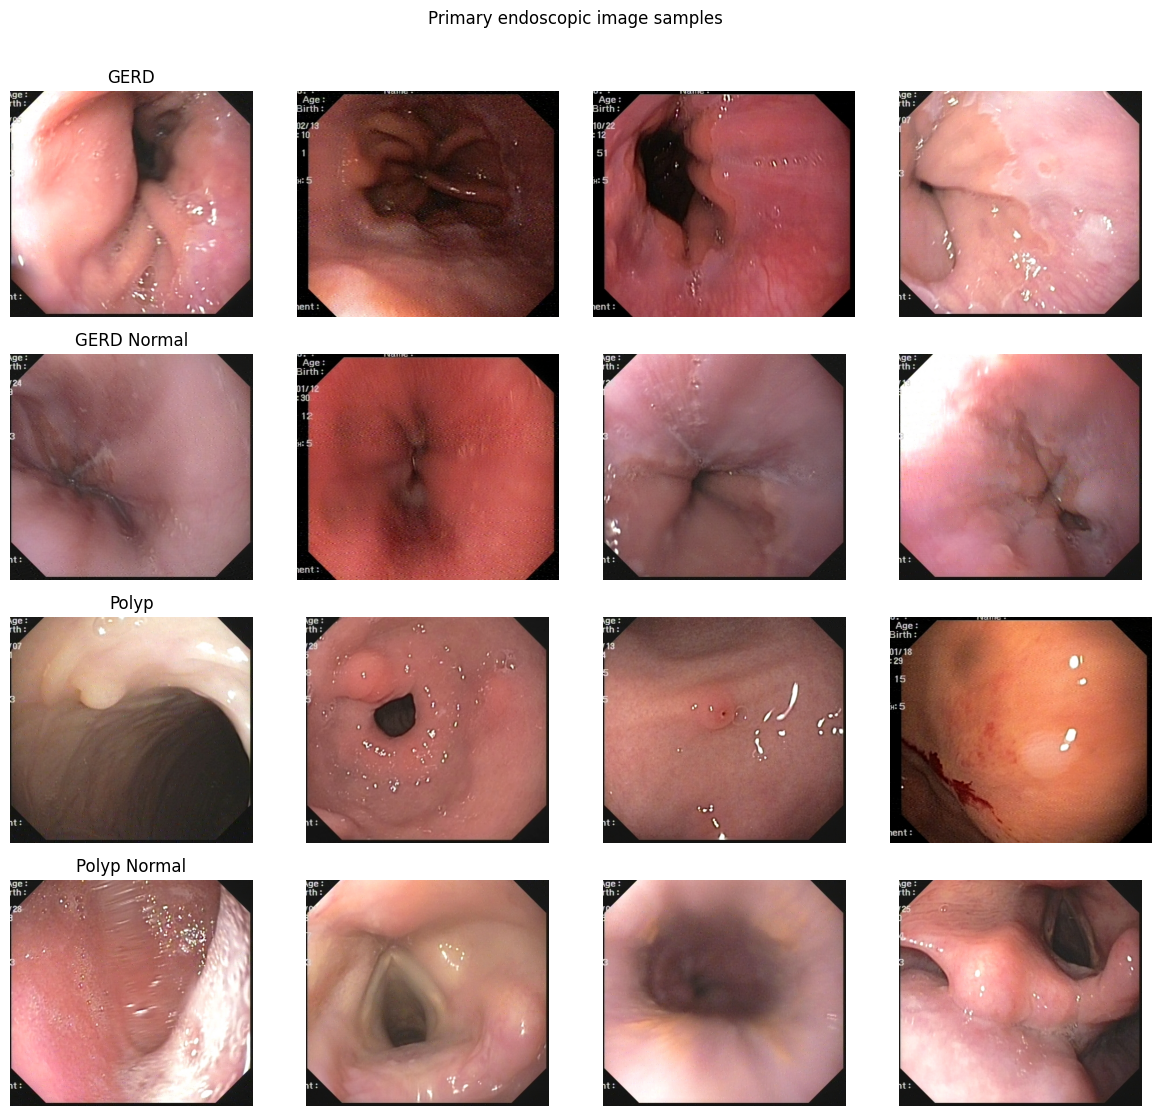

**Research finding.** The verified analysis set contains **4,004** primary images. Exact duplicate removal affected **2** files. Class imbalance is handled with training-only class weights; validation and test sets retain their natural stratified proportions.

In [ ]:
# ============================================================
# Class distribution, image properties, and sample images
# ============================================================
sampled_for_properties = primary_manifest.sample(
    n=min(500, len(primary_manifest)), random_state=SEED
)
properties = []
for path in sampled_for_properties["path"]:
    with Image.open(path) as image:
        properties.append({
            "width": image.width,
            "height": image.height,
            "mode": image.mode,
            "aspect_ratio": image.width / max(image.height, 1),
        })
property_df = pd.DataFrame(properties)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(
    data=primary_manifest, x="label", order=CLASS_NAMES,
    palette="Set2", hue="label", legend=False, ax=axes[0]
)
axes[0].set_title("Primary-image class distribution")
axes[0].tick_params(axis="x", rotation=20)
axes[0].set_xlabel("")
axes[0].set_ylabel("Images")

sns.scatterplot(
    data=property_df, x="width", y="height", alpha=0.6, ax=axes[1]
)
axes[1].set_title("Resolution distribution (sample)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dataset_distribution.png", dpi=220, bbox_inches="tight")
plt.show()

display(property_df.describe().round(3))

fig, axes = plt.subplots(len(CLASS_NAMES), 4, figsize=(12, 11))
for row, label in enumerate(CLASS_NAMES):
    samples = primary_manifest[primary_manifest["label"] == label].sample(
        n=min(4, (primary_manifest["label"] == label).sum()), random_state=SEED
    )
    for col, (_, item) in enumerate(samples.iterrows()):
        image = Image.open(item["path"]).convert("RGB")
        axes[row, col].imshow(image)
        axes[row, col].axis("off")
        axes[row, col].set_title(label if col == 0 else "")
plt.suptitle("Primary endoscopic image samples", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "primary_samples.png", dpi=220, bbox_inches="tight")
plt.show()

display(Markdown(
    f"**Research finding.** The verified analysis set contains **{len(primary_manifest):,}** "
    f"primary images. Exact duplicate removal affected **{duplicate_count}** files. "
    "Class imbalance is handled with training-only class weights; validation and test "
    "sets retain their natural stratified proportions."
))


## 6. Leakage-Controlled Train, Validation, and Test Split

The primary images are split once using stratification. Augmentation is never applied
before this split. The test set remains untouched until final evaluation.

**Dataset limitation:** patient identifiers are not provided in the public release.
Therefore, patient-level separation cannot be verified and must be reported as a
limitation.


In [ ]:
# ============================================================
# Fixed stratified split before online augmentation
# ============================================================
train_df, temp_df = train_test_split(
    primary_manifest,
    test_size=VAL_SIZE + TEST_SIZE,
    stratify=primary_manifest["label"],
    random_state=SEED,
)
relative_test = TEST_SIZE / (VAL_SIZE + TEST_SIZE)
val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test,
    stratify=temp_df["label"],
    random_state=SEED,
)

def limited_stratified(df, per_class):
    parts = []
    for label in CLASS_NAMES:
        part = df[df["label"] == label]
        parts.append(part.sample(n=min(per_class, len(part)), random_state=SEED))
    return pd.concat(parts).sample(frac=1, random_state=SEED).reset_index(drop=True)

if FAST_RUN:
    train_df = limited_stratified(train_df, FAST_TRAIN_PER_CLASS)
    val_df = limited_stratified(val_df, FAST_VAL_PER_CLASS)
    test_df = limited_stratified(test_df, FAST_TEST_PER_CLASS)

split_frames = []
for split_name, frame in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    part = frame.copy()
    part["split"] = split_name
    split_frames.append(part)
split_manifest = pd.concat(split_frames, ignore_index=True)

leakage_by_path = (
    set(train_df["path"]) & set(val_df["path"])
    or set(train_df["path"]) & set(test_df["path"])
    or set(val_df["path"]) & set(test_df["path"])
)
leakage_by_hash = (
    set(train_df["md5"]) & set(val_df["md5"])
    or set(train_df["md5"]) & set(test_df["md5"])
    or set(val_df["md5"]) & set(test_df["md5"])
)
assert not leakage_by_path, "Path leakage detected across splits."
assert not leakage_by_hash, "Exact-image leakage detected across splits."

split_table = pd.crosstab(split_manifest["split"], split_manifest["label"])
split_table = split_table.reindex(
    index=["train", "validation", "test"], columns=CLASS_NAMES, fill_value=0
)
split_table["Total"] = split_table.sum(axis=1)
display(split_table)

audit_table = pd.DataFrame({
    "Audit": [
        "Split performed on primary images",
        "Online augmentation restricted to training",
        "Overlapping paths",
        "Overlapping exact image hashes",
        "Patient-level split available",
    ],
    "Result": ["Yes", "Yes", 0, 0, "No: identifiers unavailable"],
})
display(audit_table)
split_manifest.to_csv(RESULTS_DIR / "fixed_split_manifest.csv", index=False)


label,GERD,GERD Normal,Polyp,Polyp Normal,Total
split,,,,,
train,682,771,545,804,2802
validation,146,165,117,173,601
test,146,166,117,172,601


,Audit,Result
0,Split performed on primary images,Yes
1,Online augmentation restricted to training,Yes
2,Overlapping paths,0
3,Overlapping exact image hashes,0
4,Patient-level split available,No: identifiers unavailable


## 7. Enhancement Methods and Data Pipeline

Four deterministic enhancement strategies are compared against raw RGB input:

- **CLAHE:** local contrast enhancement on the luminance channel.
- **Gamma correction:** fixed gamma of 0.80 to increase darker-region visibility.
- **Sharpening:** unsharp masking with fixed parameters.
- **CLAHE + gamma:** sequential contrast and illumination correction.

Geometric augmentation is applied only during training and is held constant across
experiments.


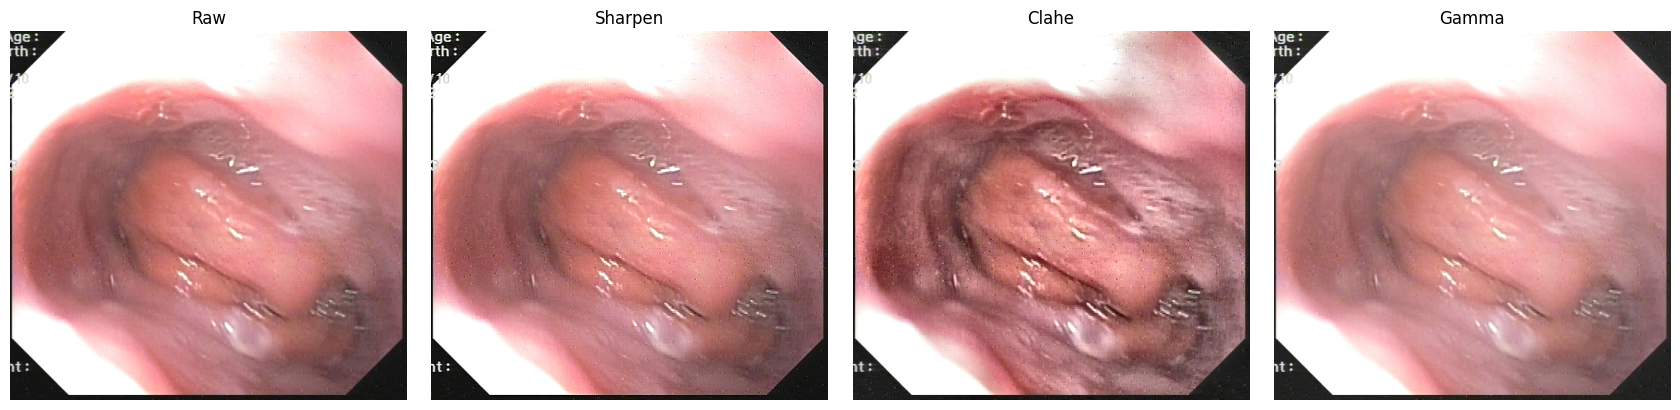

In [ ]:
# ============================================================
# Deterministic enhancement functions
# ============================================================
def apply_clahe(rgb):
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_l = clahe.apply(l_channel)
    enhanced = cv2.merge((enhanced_l, a_channel, b_channel))
    return cv2.cvtColor(enhanced, cv2.COLOR_LAB2RGB)

def apply_gamma(rgb, gamma=0.80):
    normalized = rgb.astype(np.float32) / 255.0
    corrected = np.power(normalized, gamma)
    return np.clip(corrected * 255.0, 0, 255).astype(np.uint8)

def apply_sharpen(rgb, sigma=1.0, amount=0.8):
    blurred = cv2.GaussianBlur(rgb, (0, 0), sigmaX=sigma)
    return cv2.addWeighted(rgb, 1.0 + amount, blurred, -amount, 0)

def enhance_image(rgb, mode):
    if mode == "raw":
        return rgb
    if mode == "clahe":
        return apply_clahe(rgb)
    if mode == "gamma":
        return apply_gamma(rgb)
    if mode == "sharpen":
        return apply_sharpen(rgb)
    if mode == "clahe_gamma":
        return apply_gamma(apply_clahe(rgb))
    raise ValueError(f"Unknown enhancement mode: {mode}")

example_path = primary_manifest.sample(1, random_state=SEED)["path"].iloc[0]
example_rgb = np.array(Image.open(example_path).convert("RGB"))
fig, axes = plt.subplots(1, len(ENHANCEMENT_MODES), figsize=(17, 4))
for axis, mode in zip(axes, ENHANCEMENT_MODES):
    axis.imshow(enhance_image(example_rgb.copy(), mode))
    axis.set_title(mode.replace("_", " ").title())
    axis.axis("off")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "enhancement_examples.png", dpi=220, bbox_inches="tight")
plt.show()


In [ ]:
# ============================================================
# PyTorch datasets and loaders
# ============================================================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def apply_degradation(rgb, mode, sample_seed=SEED):
    if mode is None or mode == "clean":
        return rgb
    if mode == "blur":
        return cv2.GaussianBlur(rgb, (5, 5), sigmaX=1.5)
    if mode == "brightness":
        return np.clip(rgb.astype(np.float32) * 0.70, 0, 255).astype(np.uint8)
    if mode == "noise":
        rng = np.random.default_rng(sample_seed)
        noise = rng.normal(0, 15, rgb.shape)
        return np.clip(rgb.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    raise ValueError(f"Unknown degradation mode: {mode}")

class EndoscopyDataset(Dataset):
    def __init__(self, frame, enhancement="raw", training=False, degradation="clean"):
        self.frame = frame.reset_index(drop=True)
        self.enhancement = enhancement
        self.training = training
        self.degradation = degradation
        self.transform = train_transform if training else eval_transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        item = self.frame.iloc[index]
        rgb = np.array(Image.open(item["path"]).convert("RGB"))
        rgb = enhance_image(rgb, self.enhancement)
        sample_seed = SEED + int(hashlib.md5(item["path"].encode()).hexdigest()[:8], 16)
        rgb = apply_degradation(rgb, self.degradation, sample_seed)
        image = self.transform(Image.fromarray(rgb))
        return image, int(item["label_idx"]), item["path"]

def make_loaders(enhancement="raw", degradation="clean"):
    generator = torch.Generator().manual_seed(SEED)
    common = dict(
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        pin_memory=AMP_ENABLED,
        persistent_workers=NUM_WORKERS > 0,
    )
    train_loader = DataLoader(
        EndoscopyDataset(train_df, enhancement, training=True),
        shuffle=True, generator=generator, **common
    )
    val_loader = DataLoader(
        EndoscopyDataset(val_df, enhancement, training=False),
        shuffle=False, **common
    )
    test_loader = DataLoader(
        EndoscopyDataset(test_df, enhancement, training=False, degradation=degradation),
        shuffle=False, **common
    )
    return train_loader, val_loader, test_loader

train_labels = train_df["label_idx"].to_numpy()
class_counts = np.bincount(train_labels, minlength=len(CLASS_NAMES))
class_weights = len(train_labels) / (len(CLASS_NAMES) * class_counts)
CLASS_WEIGHTS = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
display(pd.DataFrame({
    "Class": CLASS_NAMES,
    "Training images": class_counts,
    "Loss weight": class_weights.round(4),
}))


,Class,Training images,Loss weight
0,GERD,682,1.0271
1,GERD Normal,771,0.9086
2,Polyp,545,1.2853
3,Polyp Normal,804,0.8713


## 8. Model Construction and Training Utilities

All models use ImageNet initialization, the same training split, weighted
cross-entropy, label smoothing, AdamW, cosine learning-rate scheduling, early stopping,
and macro F1 as the model-selection criterion.


In [ ]:
# ============================================================
# Model factory and training loop
# ============================================================
def build_model(model_name, num_classes=4, use_pretrained=None):
    if use_pretrained is None:
        use_pretrained = USE_PRETRAINED
    if model_name == "resnet50":
        weights = models.ResNet50_Weights.DEFAULT if use_pretrained else None
        model = models.resnet50(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == "efficientnet_b0":
        weights = models.EfficientNet_B0_Weights.DEFAULT if use_pretrained else None
        model = models.efficientnet_b0(weights=weights)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif model_name == "convnext_tiny":
        weights = models.ConvNeXt_Tiny_Weights.DEFAULT if use_pretrained else None
        model = models.convnext_tiny(weights=weights)
        model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)
    else:
        raise ValueError(f"Unknown model: {model_name}")
    return model

def set_backbone_trainable(model, trainable):
    for parameter in model.parameters():
        parameter.requires_grad = trainable
    if hasattr(model, "fc"):
        for parameter in model.fc.parameters():
            parameter.requires_grad = True
    if hasattr(model, "classifier"):
        for parameter in model.classifier.parameters():
            parameter.requires_grad = True

@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    all_probabilities, all_targets, all_paths = [], [], []
    for images, targets, paths in loader:
        images = images.to(DEVICE, non_blocking=True)
        logits = model(images)
        probabilities = torch.softmax(logits, dim=1)
        all_probabilities.append(probabilities.cpu().numpy())
        all_targets.append(targets.numpy())
        all_paths.extend(paths)
    return (
        np.concatenate(all_targets),
        np.concatenate(all_probabilities),
        np.array(all_paths),
    )

def metric_bundle(y_true, probabilities):
    predictions = probabilities.argmax(axis=1)
    y_binary = label_binarize(y_true, classes=np.arange(len(CLASS_NAMES)))
    metrics = {
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "macro_precision": precision_score(y_true, predictions, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, predictions, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, predictions, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, predictions, average="weighted", zero_division=0),
        "log_loss": log_loss(y_true, probabilities, labels=np.arange(len(CLASS_NAMES))),
    }
    try:
        metrics["roc_auc_ovr_macro"] = roc_auc_score(
            y_true, probabilities, multi_class="ovr", average="macro"
        )
        metrics["pr_auc_macro"] = average_precision_score(
            y_binary, probabilities, average="macro"
        )
    except ValueError:
        metrics["roc_auc_ovr_macro"] = np.nan
        metrics["pr_auc_macro"] = np.nan
    return metrics

def fit_model(model_name, enhancement, train_loader, val_loader):
    experiment_id = f"{model_name}__{enhancement}"
    checkpoint_path = MODELS_DIR / f"{experiment_id}.pt"
    history_path = RESULTS_DIR / f"history_{experiment_id}.csv"

    if (
        RESUME_COMPLETED_EXPERIMENTS
        and checkpoint_path.exists()
        and history_path.exists()
    ):
        print(f"Loading completed experiment from Drive: {experiment_id}")
        model = build_model(model_name, use_pretrained=False).to(DEVICE)
        model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
        history_df = pd.read_csv(history_path)
        return model, history_df, 0.0, checkpoint_path

    # Reset initialization and stochastic training state for fair comparisons.
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    model = build_model(model_name).to(DEVICE)
    set_backbone_trainable(model, trainable=False)

    criterion = nn.CrossEntropyLoss(
        weight=CLASS_WEIGHTS, label_smoothing=LABEL_SMOOTHING
    )
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=max(EFFECTIVE_EPOCHS, 1)
    )
    scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

    best_f1 = -np.inf
    wait = 0
    history = []
    start_time = time.perf_counter()

    for epoch in range(EFFECTIVE_EPOCHS):
        if epoch == min(FREEZE_EPOCHS, max(EFFECTIVE_EPOCHS - 1, 0)):
            set_backbone_trainable(model, trainable=True)

        model.train()
        epoch_loss = 0.0
        seen = 0
        for images, targets, _ in train_loader:
            images = images.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
                logits = model(images)
                loss = criterion(logits, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            epoch_loss += loss.item() * images.size(0)
            seen += images.size(0)

        y_val, p_val, _ = predict_loader(model, val_loader)
        val_metrics = metric_bundle(y_val, p_val)
        row = {
            "epoch": epoch + 1,
            "train_loss": epoch_loss / max(seen, 1),
            "learning_rate": optimizer.param_groups[0]["lr"],
            **{f"val_{key}": value for key, value in val_metrics.items()},
        }
        history.append(row)
        scheduler.step()

        print(
            f"{experiment_id} | epoch {epoch + 1:02d}/{EFFECTIVE_EPOCHS} | "
            f"loss={row['train_loss']:.4f} | val_f1={row['val_macro_f1']:.4f}"
        )

        if row["val_macro_f1"] > best_f1 + 1e-5:
            best_f1 = row["val_macro_f1"]
            wait = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"Early stopping at epoch {epoch + 1}.")
                break

    training_seconds = time.perf_counter() - start_time
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    history_df = pd.DataFrame(history)
    history_df.to_csv(history_path, index=False)
    return model, history_df, training_seconds, checkpoint_path


## 9. Balanced Single-View Experiment Matrix

Every backbone is trained on exactly the same four image views. This produces
**12 trained models** and avoids giving ConvNeXt-Tiny additional enhancement trials.
Validation and test probabilities are retained for leakage-free fusion.


In [ ]:
# ============================================================
# Experiments 1–12: three backbones x four matched image views
# ============================================================
experiment_results = []
experiment_predictions = {}
validation_predictions = {}
experiment_histories = {}
experiment_checkpoints = {}

for model_name in BACKBONE_MODELS:
    for view in SINGLE_VIEW_MODES:
        experiment_id = f"{model_name}__{view}"
        print(f"\n===== {experiment_id} =====")
        train_loader, val_loader, test_loader = make_loaders(view)
        model, history, training_seconds, checkpoint = fit_model(
            model_name, view, train_loader, val_loader
        )

        y_val, p_val, val_paths = predict_loader(model, val_loader)
        y_test, p_test, test_paths = predict_loader(model, test_loader)
        metrics = metric_bundle(y_test, p_test)

        experiment_results.append({
            "experiment_id": experiment_id,
            "model": model_name,
            "configuration": view,
            "enhancement": view,
            "configuration_type": "single_view",
            "best_val_macro_f1": history["val_macro_f1"].max(),
            "best_epoch": int(history.loc[history["val_macro_f1"].idxmax(), "epoch"]),
            "training_seconds": training_seconds,
            **metrics,
        })
        validation_predictions[experiment_id] = {
            "y_true": y_val, "probabilities": p_val, "paths": val_paths
        }
        experiment_predictions[experiment_id] = {
            "y_true": y_test, "probabilities": p_test, "paths": test_paths
        }
        experiment_histories[experiment_id] = history
        experiment_checkpoints[experiment_id] = checkpoint

        del model, train_loader, val_loader, test_loader
        gc.collect()
        torch.cuda.empty_cache()

single_view_results = pd.DataFrame(experiment_results)
single_view_results = single_view_results.sort_values(
    ["model", "configuration"]
).reset_index(drop=True)
display(single_view_results.round(4))
single_view_results.to_csv(
    RESULTS_DIR / "balanced_single_view_results.csv", index=False
)

single_view_f1_matrix = single_view_results.pivot(
    index="model", columns="configuration", values="macro_f1"
).reindex(index=BACKBONE_MODELS, columns=SINGLE_VIEW_MODES)
display(single_view_f1_matrix.round(4))
single_view_f1_matrix.to_csv(
    RESULTS_DIR / "single_view_macro_f1_matrix.csv"
)



===== resnet50__raw =====
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 171MB/s]


resnet50__raw | epoch 01/15 | loss=1.2623 | val_f1=0.5744
resnet50__raw | epoch 02/15 | loss=1.0974 | val_f1=0.6040
resnet50__raw | epoch 03/15 | loss=0.7683 | val_f1=0.7705
resnet50__raw | epoch 04/15 | loss=0.5661 | val_f1=0.8186
resnet50__raw | epoch 05/15 | loss=0.4613 | val_f1=0.8207
resnet50__raw | epoch 06/15 | loss=0.3874 | val_f1=0.8469
resnet50__raw | epoch 07/15 | loss=0.3410 | val_f1=0.8528
resnet50__raw | epoch 08/15 | loss=0.2940 | val_f1=0.8587
resnet50__raw | epoch 09/15 | loss=0.2660 | val_f1=0.8507
resnet50__raw | epoch 10/15 | loss=0.2461 | val_f1=0.8633
resnet50__raw | epoch 11/15 | loss=0.2375 | val_f1=0.8579
resnet50__raw | epoch 12/15 | loss=0.2293 | val_f1=0.8704
resnet50__raw | epoch 13/15 | loss=0.2251 | val_f1=0.8671
resnet50__raw | epoch 14/15 | loss=0.2218 | val_f1=0.8716
resnet50__raw | epoch 15/15 | loss=0.2226 | val_f1=0.8682

===== resnet50__sharpen =====
Loading completed experiment from Drive: resnet50__sharpen

===== resnet50__clahe =====
resnet50__c

100%|██████████| 20.5M/20.5M [00:00<00:00, 77.2MB/s]


efficientnet_b0__raw | epoch 01/15 | loss=1.2477 | val_f1=0.6155
efficientnet_b0__raw | epoch 02/15 | loss=1.0687 | val_f1=0.6388
efficientnet_b0__raw | epoch 03/15 | loss=0.7768 | val_f1=0.7855
efficientnet_b0__raw | epoch 04/15 | loss=0.5504 | val_f1=0.8344
efficientnet_b0__raw | epoch 05/15 | loss=0.4509 | val_f1=0.8511
efficientnet_b0__raw | epoch 06/15 | loss=0.3795 | val_f1=0.8219
efficientnet_b0__raw | epoch 07/15 | loss=0.3406 | val_f1=0.8539
efficientnet_b0__raw | epoch 08/15 | loss=0.3020 | val_f1=0.8499
efficientnet_b0__raw | epoch 09/15 | loss=0.2824 | val_f1=0.8468
efficientnet_b0__raw | epoch 10/15 | loss=0.2627 | val_f1=0.8628
efficientnet_b0__raw | epoch 11/15 | loss=0.2548 | val_f1=0.8687
efficientnet_b0__raw | epoch 12/15 | loss=0.2549 | val_f1=0.8633
efficientnet_b0__raw | epoch 13/15 | loss=0.2567 | val_f1=0.8468
efficientnet_b0__raw | epoch 14/15 | loss=0.2463 | val_f1=0.8606
efficientnet_b0__raw | epoch 15/15 | loss=0.2454 | val_f1=0.8692

===== efficientnet_b0__s

100%|██████████| 109M/109M [00:01<00:00, 110MB/s]


convnext_tiny__raw | epoch 01/15 | loss=1.1772 | val_f1=0.6110
convnext_tiny__raw | epoch 02/15 | loss=0.9547 | val_f1=0.6393
convnext_tiny__raw | epoch 03/15 | loss=0.8336 | val_f1=0.8192
convnext_tiny__raw | epoch 04/15 | loss=0.5954 | val_f1=0.8305
convnext_tiny__raw | epoch 05/15 | loss=0.4482 | val_f1=0.8224
convnext_tiny__raw | epoch 06/15 | loss=0.3848 | val_f1=0.8609
convnext_tiny__raw | epoch 07/15 | loss=0.3098 | val_f1=0.8685
convnext_tiny__raw | epoch 08/15 | loss=0.2653 | val_f1=0.8405
convnext_tiny__raw | epoch 09/15 | loss=0.2531 | val_f1=0.8674
convnext_tiny__raw | epoch 10/15 | loss=0.2258 | val_f1=0.8600
convnext_tiny__raw | epoch 11/15 | loss=0.2171 | val_f1=0.8710
convnext_tiny__raw | epoch 12/15 | loss=0.2163 | val_f1=0.8705
convnext_tiny__raw | epoch 13/15 | loss=0.2167 | val_f1=0.8755
convnext_tiny__raw | epoch 14/15 | loss=0.2128 | val_f1=0.8745
convnext_tiny__raw | epoch 15/15 | loss=0.2143 | val_f1=0.8726

===== convnext_tiny__sharpen =====
convnext_tiny__shar

,experiment_id,model,configuration,enhancement,configuration_type,best_val_macro_f1,best_epoch,training_seconds,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,log_loss,roc_auc_ovr_macro,pr_auc_macro
0,convnext_tiny__clahe,convnext_tiny,clahe,clahe,single_view,0.8877,12,0.0000,0.8735,0.8751,0.8758,0.8751,0.8752,0.8739,0.3730,0.9740,0.9350
1,convnext_tiny__gamma,convnext_tiny,gamma,gamma,single_view,0.8833,11,744.3117,0.8602,0.8602,0.8645,0.8602,0.8618,0.8608,0.4112,0.9697,0.9241
2,convnext_tiny__raw,convnext_tiny,raw,raw,single_view,0.8755,13,541.7972,0.8669,0.8662,0.8697,0.8662,0.8677,0.8671,0.4172,0.9640,0.9055
3,convnext_tiny__sharpen,convnext_tiny,sharpen,sharpen,single_view,0.8721,6,393.9349,0.8652,0.8623,0.8697,0.8623,0.8653,0.8653,0.3894,0.9710,0.9267
4,efficientnet_b0__clahe,efficientnet_b0,clahe,clahe,single_view,0.8733,14,0.0000,0.8436,0.8440,0.8440,0.8440,0.8435,0.8433,0.4254,0.9658,0.9099
5,efficientnet_b0__gamma,efficientnet_b0,gamma,gamma,single_view,0.8574,15,703.6495,0.8652,0.8635,0.8664,0.8635,0.8648,0.8653,0.4102,0.9636,0.9185
6,efficientnet_b0__raw,efficientnet_b0,raw,raw,single_view,0.8692,15,492.8634,0.8586,0.8561,0.8627,0.8561,0.8587,0.8587,0.4173,0.9623,0.9116
7,efficientnet_b0__sharpen,efficientnet_b0,sharpen,sharpen,single_view,0.8703,15,554.3884,0.8552,0.8528,0.8578,0.8528,0.8548,0.8554,0.4331,0.9606,0.9036
8,resnet50__clahe,resnet50,clahe,clahe,single_view,0.8577,11,859.2892,0.8619,0.8610,0.8653,0.8610,0.8628,0.8621,0.4405,0.9583,0.9065
9,resnet50__gamma,resnet50,gamma,gamma,single_view,0.8536,6,475.9315,0.8453,0.8465,0.8461,0.8465,0.8442,0.8454,0.4405,0.9629,0.9083


configuration,raw,sharpen,clahe,gamma
model,,,,
resnet50,0.8549,0.8622,0.8628,0.8442
efficientnet_b0,0.8587,0.8548,0.8435,0.8648
convnext_tiny,0.8677,0.8653,0.8752,0.8618


## 10. Proposed Validation-Weighted Multi-Model Ensemble

One configuration is selected independently for each backbone using validation macro-F1.
Non-negative fusion weights that sum to one are then searched exclusively on aligned
validation probabilities. Candidate weights are ranked first by validation macro-F1 and
then by validation log loss.

The held-out test set is never used to select component models or fusion weights. The
proposed ensemble requires no model retraining and does not alter the 12 primary results.


In [ ]:
# ============================================================
# Experiment 13: proposed validation-weighted soft-voting ensemble
# ============================================================
def assert_aligned(prediction_sets, label):
    reference = prediction_sets[0]
    for current in prediction_sets[1:]:
        assert np.array_equal(reference["y_true"], current["y_true"]), (
            f"Label order differs in {label}."
        )
        assert np.array_equal(reference["paths"], current["paths"]), (
            f"Image order differs in {label}."
        )

def probability_fusion(probability_list, weights):
    weights = np.asarray(weights, dtype=np.float64)
    assert np.all(weights >= 0), "Fusion weights must be non-negative."
    assert weights.sum() > 0, "At least one fusion weight must be positive."
    weights = weights / weights.sum()
    stacked = np.stack(probability_list, axis=1)
    return np.sum(stacked * weights[None, :, None], axis=1)

# Stage 1: select one representation per backbone using validation macro-F1 only.
selected_component_rows = []
selected_ids = []
for model_name in BACKBONE_MODELS:
    model_rows = single_view_results[
        single_view_results["model"] == model_name
    ].sort_values(
        ["best_val_macro_f1", "configuration"],
        ascending=[False, True],
    )
    selected_row = model_rows.iloc[0]
    selected_ids.append(selected_row["experiment_id"])
    selected_component_rows.append({
        "model": model_name,
        "selected_experiment": selected_row["experiment_id"],
        "selected_view": selected_row["configuration"],
        "validation_macro_f1": selected_row["best_val_macro_f1"],
        "test_macro_f1": selected_row["macro_f1"],
    })

selected_components = pd.DataFrame(selected_component_rows)
display(selected_components.round(4))
selected_components.to_csv(
    RESULTS_DIR / "ensemble_selected_components.csv", index=False
)

val_sets = [validation_predictions[x] for x in selected_ids]
test_sets = [experiment_predictions[x] for x in selected_ids]
assert_aligned(val_sets, "ensemble validation predictions")
assert_aligned(test_sets, "ensemble test predictions")

y_val = val_sets[0]["y_true"]
y_test = test_sets[0]["y_true"]
val_probability_list = [x["probabilities"] for x in val_sets]
test_probability_list = [x["probabilities"] for x in test_sets]

# Stage 2: exhaustive three-weight search on validation data only.
weight_grid_rows = []
best_candidate = None
units = int(round(1.0 / ENSEMBLE_WEIGHT_STEP))
for first in range(1, units - 1):
    for second in range(1, units - first):
        third = units - first - second
        if third < 1:
            continue
        weights = np.array([first, second, third], dtype=float) / units
        probabilities = probability_fusion(val_probability_list, weights)
        metrics = metric_bundle(y_val, probabilities)
        candidate = {
            "weights": weights,
            "macro_f1": metrics["macro_f1"],
            "log_loss": metrics["log_loss"],
        }
        weight_grid_rows.append({
            **{
                f"weight_{model}": weight
                for model, weight in zip(BACKBONE_MODELS, weights)
            },
            "validation_macro_f1": metrics["macro_f1"],
            "validation_log_loss": metrics["log_loss"],
        })
        score = (candidate["macro_f1"], -candidate["log_loss"])
        if best_candidate is None or score > best_candidate["score"]:
            best_candidate = {**candidate, "score": score}

assert best_candidate is not None, "Validation weight search returned no candidate."
selected_weights = best_candidate["weights"]
p_val_weighted = probability_fusion(val_probability_list, selected_weights)
p_test_weighted = probability_fusion(test_probability_list, selected_weights)
weighted_id = "multi_model__validation_weighted_soft_voting"

weighted_val_metrics = metric_bundle(y_val, p_val_weighted)
weighted_test_metrics = metric_bundle(y_test, p_test_weighted)
experiment_results.append({
    "experiment_id": weighted_id,
    "model": "multi_model",
    "configuration": "validation_weighted_soft_voting",
    "enhancement": "validation_selected",
    "configuration_type": "proposed_ensemble",
    "best_val_macro_f1": weighted_val_metrics["macro_f1"],
    "best_epoch": np.nan,
    "training_seconds": 0.0,
    **{
        f"weight_{model}": weight
        for model, weight in zip(BACKBONE_MODELS, selected_weights)
    },
    **weighted_test_metrics,
})
validation_predictions[weighted_id] = {
    "y_true": y_val,
    "probabilities": p_val_weighted,
    "paths": val_sets[0]["paths"],
}
experiment_predictions[weighted_id] = {
    "y_true": y_test,
    "probabilities": p_test_weighted,
    "paths": test_sets[0]["paths"],
}

weight_search_table = pd.DataFrame(weight_grid_rows).sort_values(
    ["validation_macro_f1", "validation_log_loss"],
    ascending=[False, True],
).reset_index(drop=True)
weight_search_table.to_csv(
    RESULTS_DIR / "ensemble_validation_weight_search.csv", index=False
)

all_results = pd.DataFrame(experiment_results).sort_values(
    "macro_f1", ascending=False
).reset_index(drop=True)
all_results.to_csv(RESULTS_DIR / "all_results_with_proposed_ensemble.csv", index=False)
display(all_results.round(4))

proposed_ensemble_summary = all_results[
    all_results["experiment_id"] == weighted_id
].copy()
display(proposed_ensemble_summary.round(4))
display(Markdown(
    "**Selected validation weights:** " +
    ", ".join(
        f"{model}={weight:.2f}"
        for model, weight in zip(BACKBONE_MODELS, selected_weights)
    )
))


,model,selected_experiment,selected_view,validation_macro_f1,test_macro_f1
0,resnet50,resnet50__sharpen,sharpen,0.8732,0.8622
1,efficientnet_b0,efficientnet_b0__clahe,clahe,0.8733,0.8435
2,convnext_tiny,convnext_tiny__clahe,clahe,0.8877,0.8752


,experiment_id,model,configuration,enhancement,configuration_type,best_val_macro_f1,best_epoch,training_seconds,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,log_loss,roc_auc_ovr_macro,pr_auc_macro,weight_resnet50,weight_efficientnet_b0,weight_convnext_tiny
0,multi_model__validation_weighted_soft_voting,multi_model,validation_weighted_soft_voting,validation_selected,proposed_ensemble,0.9039,NaN,0.0000,0.8918,0.8924,0.8947,0.8924,0.8935,0.8921,0.3373,0.9785,0.9458,0.3,0.25,0.45
1,convnext_tiny__clahe,convnext_tiny,clahe,clahe,single_view,0.8877,12.0,0.0000,0.8735,0.8751,0.8758,0.8751,0.8752,0.8739,0.3730,0.9740,0.9350,NaN,NaN,NaN
2,convnext_tiny__raw,convnext_tiny,raw,raw,single_view,0.8755,13.0,541.7972,0.8669,0.8662,0.8697,0.8662,0.8677,0.8671,0.4172,0.9640,0.9055,NaN,NaN,NaN
3,convnext_tiny__sharpen,convnext_tiny,sharpen,sharpen,single_view,0.8721,6.0,393.9349,0.8652,0.8623,0.8697,0.8623,0.8653,0.8653,0.3894,0.9710,0.9267,NaN,NaN,NaN
4,efficientnet_b0__gamma,efficientnet_b0,gamma,gamma,single_view,0.8574,15.0,703.6495,0.8652,0.8635,0.8664,0.8635,0.8648,0.8653,0.4102,0.9636,0.9185,NaN,NaN,NaN
5,resnet50__clahe,resnet50,clahe,clahe,single_view,0.8577,11.0,859.2892,0.8619,0.8610,0.8653,0.8610,0.8628,0.8621,0.4405,0.9583,0.9065,NaN,NaN,NaN
6,resnet50__sharpen,resnet50,sharpen,sharpen,single_view,0.8732,11.0,0.0000,0.8619,0.8598,0.8661,0.8598,0.8622,0.8619,0.4138,0.9627,0.9141,NaN,NaN,NaN
7,convnext_tiny__gamma,convnext_tiny,gamma,gamma,single_view,0.8833,11.0,744.3117,0.8602,0.8602,0.8645,0.8602,0.8618,0.8608,0.4112,0.9697,0.9241,NaN,NaN,NaN
8,efficientnet_b0__raw,efficientnet_b0,raw,raw,single_view,0.8692,15.0,492.8634,0.8586,0.8561,0.8627,0.8561,0.8587,0.8587,0.4173,0.9623,0.9116,NaN,NaN,NaN
9,resnet50__raw,resnet50,raw,raw,single_view,0.8716,14.0,492.5835,0.8552,0.8524,0.8586,0.8524,0.8549,0.8549,0.4230,0.9661,0.9206,NaN,NaN,NaN


,experiment_id,model,configuration,enhancement,configuration_type,best_val_macro_f1,best_epoch,training_seconds,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,log_loss,roc_auc_ovr_macro,pr_auc_macro,weight_resnet50,weight_efficientnet_b0,weight_convnext_tiny
0,multi_model__validation_weighted_soft_voting,multi_model,validation_weighted_soft_voting,validation_selected,proposed_ensemble,0.9039,NaN,0.0,0.8918,0.8924,0.8947,0.8924,0.8935,0.8921,0.3373,0.9785,0.9458,0.3,0.25,0.45


**Selected validation weights:** resnet50=0.30, efficientnet_b0=0.25, convnext_tiny=0.45

## 11. Enhancement Effects and Validation-Based References

This section reports each enhancement relative to the raw version of the same backbone.
It also compares the ensemble with the strongest validation-selected individual
model. All selection decisions are made without consulting test-set performance.


In [ ]:
enhancement_effect_rows = []
for model_name in BACKBONE_MODELS:
    model_rows = single_view_results[single_view_results["model"] == model_name]
    raw_row = model_rows[model_rows["configuration"] == "raw"].iloc[0]
    for view in ["sharpen", "clahe", "gamma"]:
        enhanced_row = model_rows[model_rows["configuration"] == view].iloc[0]
        enhancement_effect_rows.append({
            "model": model_name,
            "enhancement": view,
            "raw_accuracy": raw_row["accuracy"],
            "enhanced_accuracy": enhanced_row["accuracy"],
            "accuracy_delta": enhanced_row["accuracy"] - raw_row["accuracy"],
            "raw_macro_f1": raw_row["macro_f1"],
            "enhanced_macro_f1": enhanced_row["macro_f1"],
            "macro_f1_delta": enhanced_row["macro_f1"] - raw_row["macro_f1"],
            "raw_pr_auc": raw_row["pr_auc_macro"],
            "enhanced_pr_auc": enhanced_row["pr_auc_macro"],
            "pr_auc_delta": enhanced_row["pr_auc_macro"] - raw_row["pr_auc_macro"],
        })
enhancement_effect_table = pd.DataFrame(enhancement_effect_rows)
display(enhancement_effect_table.round(4))
enhancement_effect_table.to_csv(
    RESULTS_DIR / "cross_backbone_enhancement_effects.csv", index=False
)

# References used by robustness and detailed reporting.
convnext_single = single_view_results[
    single_view_results["model"] == "convnext_tiny"
].sort_values(["best_val_macro_f1", "configuration"], ascending=[False, True])
best_enhanced_row = convnext_single.iloc[0]
best_enhanced_id = best_enhanced_row["experiment_id"]
best_enhancement = best_enhanced_row["configuration"]

selected_single_row = single_view_results.sort_values(
    ["best_val_macro_f1", "experiment_id"], ascending=[False, True]
).iloc[0]
selected_single_id = selected_single_row["experiment_id"]
selected_single_model = selected_single_row["model"]
selected_single_view = selected_single_row["configuration"]

proposed_comparison = pd.DataFrame([
    {
        "configuration": selected_single_id,
        "role": "validation-selected individual comparator",
        "macro_f1": selected_single_row["macro_f1"],
    },
    {
        "configuration": weighted_id,
        "role": "proposed validation-weighted ensemble",
        "macro_f1": all_results.loc[
            all_results["experiment_id"] == weighted_id, "macro_f1"
        ].iloc[0],
    },
])
proposed_comparison["delta_vs_selected_individual"] = (
    proposed_comparison["macro_f1"] - selected_single_row["macro_f1"]
)
display(proposed_comparison.round(4))
proposed_comparison.to_csv(
    RESULTS_DIR / "proposed_ensemble_comparison.csv", index=False
)


,model,enhancement,raw_accuracy,enhanced_accuracy,accuracy_delta,raw_macro_f1,enhanced_macro_f1,macro_f1_delta,raw_pr_auc,enhanced_pr_auc,pr_auc_delta
0,resnet50,sharpen,0.8552,0.8619,0.0067,0.8549,0.8622,0.0073,0.9206,0.9141,-0.0065
1,resnet50,clahe,0.8552,0.8619,0.0067,0.8549,0.8628,0.0079,0.9206,0.9065,-0.0140
2,resnet50,gamma,0.8552,0.8453,-0.0100,0.8549,0.8442,-0.0107,0.9206,0.9083,-0.0122
3,efficientnet_b0,sharpen,0.8586,0.8552,-0.0033,0.8587,0.8548,-0.0039,0.9116,0.9036,-0.0080
4,efficientnet_b0,clahe,0.8586,0.8436,-0.0150,0.8587,0.8435,-0.0153,0.9116,0.9099,-0.0017
5,efficientnet_b0,gamma,0.8586,0.8652,0.0067,0.8587,0.8648,0.0061,0.9116,0.9185,0.0069
6,convnext_tiny,sharpen,0.8669,0.8652,-0.0017,0.8677,0.8653,-0.0024,0.9055,0.9267,0.0212
7,convnext_tiny,clahe,0.8669,0.8735,0.0067,0.8677,0.8752,0.0075,0.9055,0.9350,0.0295
8,convnext_tiny,gamma,0.8669,0.8602,-0.0067,0.8677,0.8618,-0.0059,0.9055,0.9241,0.0187


,configuration,role,macro_f1,delta_vs_selected_individual
0,convnext_tiny__clahe,validation-selected individual comparator,0.8752,0.0000
1,multi_model__validation_weighted_soft_voting,proposed validation-weighted ensemble,0.8935,0.0183


## 12. Statistical Uncertainty and Paired Tests

Bootstrap intervals are reported for all configurations. Exact paired McNemar tests compare
the two ensembles with the validation-selected individual model. These tests
describe prediction disagreement and do not redefine the primary multi-enhancement study.


In [ ]:
def bootstrap_ci(y_true, probabilities, metric_name, iterations=1000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    values = []
    predictions = probabilities.argmax(axis=1)
    for _ in range(iterations):
        indices = rng.integers(0, n, n)
        sampled_true = y_true[indices]
        sampled_pred = predictions[indices]
        if metric_name == "accuracy":
            value = accuracy_score(sampled_true, sampled_pred)
        elif metric_name == "macro_f1":
            value = f1_score(
                sampled_true, sampled_pred, average="macro",
                labels=np.arange(len(CLASS_NAMES)), zero_division=0
            )
        else:
            raise ValueError(metric_name)
        values.append(value)
    return np.percentile(values, [2.5, 97.5])

ci_rows = []
for experiment_id, prediction_data in experiment_predictions.items():
    for metric_name in ["accuracy", "macro_f1"]:
        point = metric_bundle(
            prediction_data["y_true"], prediction_data["probabilities"]
        )[metric_name]
        low, high = bootstrap_ci(
            prediction_data["y_true"], prediction_data["probabilities"],
            metric_name, BOOTSTRAP_ITERATIONS, SEED
        )
        ci_rows.append({
            "experiment_id": experiment_id,
            "metric": metric_name,
            "point_estimate": point,
            "ci_2.5%": low,
            "ci_97.5%": high,
        })
ci_table = pd.DataFrame(ci_rows)
display(ci_table.round(4))
ci_table.to_csv(RESULTS_DIR / "bootstrap_confidence_intervals.csv", index=False)

def paired_mcnemar(experiment_a, experiment_b, comparison):
    data_a = experiment_predictions[experiment_a]
    data_b = experiment_predictions[experiment_b]
    assert np.array_equal(data_a["paths"], data_b["paths"])
    correct_a = data_a["probabilities"].argmax(1) == data_a["y_true"]
    correct_b = data_b["probabilities"].argmax(1) == data_b["y_true"]
    a_only = int(np.sum(correct_a & ~correct_b))
    b_only = int(np.sum(~correct_a & correct_b))
    discordant = a_only + b_only
    p_value = (
        binomtest(min(a_only, b_only), discordant, 0.5).pvalue
        if discordant else 1.0
    )
    return {
        "Comparison": comparison,
        "Comparator only correct": a_only,
        "Proposed ensemble only correct": b_only,
        "Discordant pairs": discordant,
        "Exact McNemar p-value": p_value,
        "Significant (0.05)": p_value < 0.05,
    }

# One prespecified paired comparison; no multiplicity correction is required.
mcnemar_table = pd.DataFrame([
    paired_mcnemar(
        selected_single_id,
        weighted_id,
        "Validation-selected individual vs proposed validation-weighted ensemble",
    )
])
display(mcnemar_table)
mcnemar_table.to_csv(
    RESULTS_DIR / "proposed_ensemble_mcnemar_test.csv", index=False
)


,experiment_id,metric,point_estimate,ci_2.5%,ci_97.5%
0,resnet50__raw,accuracy,0.8552,0.8236,0.8835
1,resnet50__raw,macro_f1,0.8549,0.8237,0.8823
2,resnet50__sharpen,accuracy,0.8619,0.8336,0.8885
3,resnet50__sharpen,macro_f1,0.8622,0.8346,0.8876
4,resnet50__clahe,accuracy,0.8619,0.8352,0.8885
5,resnet50__clahe,macro_f1,0.8628,0.8348,0.8890
6,resnet50__gamma,accuracy,0.8453,0.8169,0.8735
7,resnet50__gamma,macro_f1,0.8442,0.8141,0.8718
8,efficientnet_b0__raw,accuracy,0.8586,0.8286,0.8852
9,efficientnet_b0__raw,macro_f1,0.8587,0.8281,0.8850


,Comparison,Comparator only correct,Proposed ensemble only correct,Discordant pairs,Exact McNemar p-value,Significant (0.05)
0,Validation-selected individual vs proposed val...,4,15,19,0.019211,True


## 13. Proposed Ensemble Class-Wise Evaluation

The confusion matrix and per-class precision, recall, and F1 scores are reported for the
proposed validation-weighted ensemble on the held-out test set.


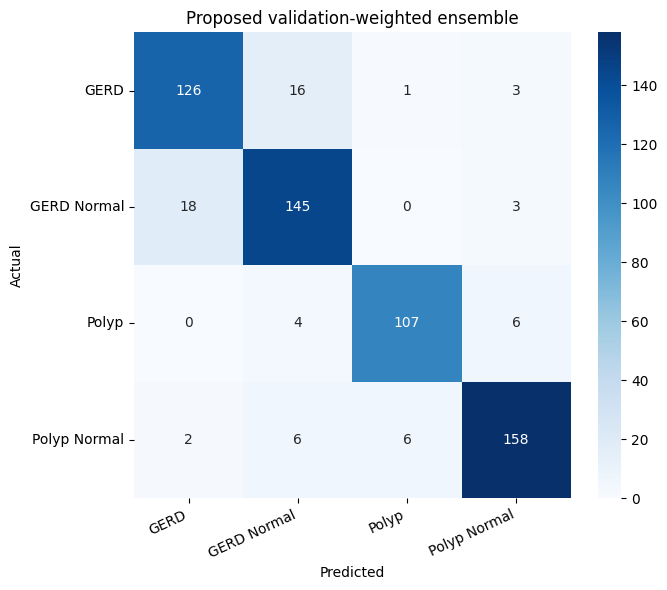

,experiment_id,class_or_average,precision,recall,f1-score,support
0,multi_model__validation_weighted_soft_voting,GERD,0.8630,0.8630,0.8630,146.0000
1,multi_model__validation_weighted_soft_voting,GERD Normal,0.8480,0.8735,0.8605,166.0000
2,multi_model__validation_weighted_soft_voting,Polyp,0.9386,0.9145,0.9264,117.0000
3,multi_model__validation_weighted_soft_voting,Polyp Normal,0.9294,0.9186,0.9240,172.0000
4,multi_model__validation_weighted_soft_voting,accuracy,0.8918,0.8918,0.8918,0.8918
5,multi_model__validation_weighted_soft_voting,macro avg,0.8947,0.8924,0.8935,601.0000
6,multi_model__validation_weighted_soft_voting,weighted avg,0.8926,0.8918,0.8921,601.0000


In [ ]:
proposed_data = experiment_predictions[weighted_id]
proposed_predictions = proposed_data["probabilities"].argmax(axis=1)
proposed_matrix = confusion_matrix(
    proposed_data["y_true"],
    proposed_predictions,
    labels=np.arange(len(CLASS_NAMES)),
)

plt.figure(figsize=(7, 6))
sns.heatmap(
    proposed_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title("Proposed validation-weighted ensemble")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=25, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "proposed_weighted_ensemble_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

class_report_table = pd.DataFrame(classification_report(
    proposed_data["y_true"],
    proposed_predictions,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)).T.reset_index(names="class_or_average")
class_report_table.insert(0, "experiment_id", weighted_id)
display(class_report_table.round(4))
class_report_table.to_csv(
    RESULTS_DIR / "proposed_weighted_classwise_performance.csv", index=False
)


## 14. Proposed Ensemble Multiclass ROC and Precision–Recall Analysis

One-vs-rest curves are generated directly from the proposed validation-weighted ensemble
probabilities.


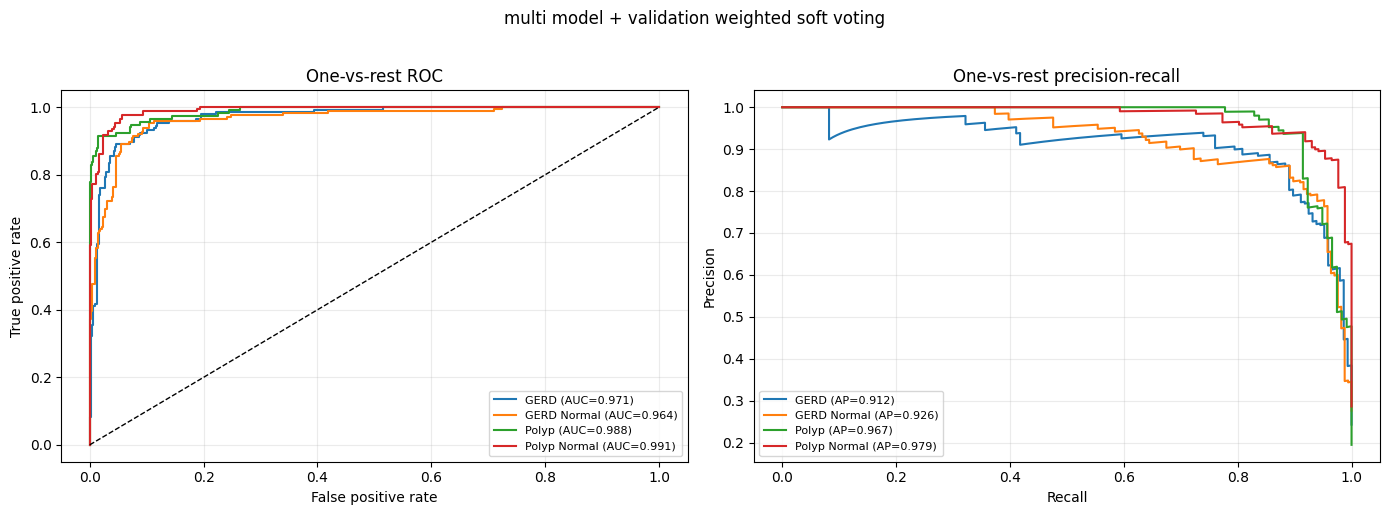

,experiment_id,class,roc_auc,average_precision
0,multi_model__validation_weighted_soft_voting,GERD,0.9711,0.9122
1,multi_model__validation_weighted_soft_voting,GERD Normal,0.9645,0.9258
2,multi_model__validation_weighted_soft_voting,Polyp,0.9876,0.9666
3,multi_model__validation_weighted_soft_voting,Polyp Normal,0.9909,0.9787


In [ ]:
# ============================================================
# One-vs-rest ROC and precision-recall curves
# ============================================================
curve_experiment_id = weighted_id
best_data = experiment_predictions[curve_experiment_id]
y_binary = label_binarize(best_data["y_true"], classes=np.arange(len(CLASS_NAMES)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
curve_rows = []
for class_idx, class_name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_binary[:, class_idx], best_data["probabilities"][:, class_idx])
    precision, recall, _ = precision_recall_curve(
        y_binary[:, class_idx], best_data["probabilities"][:, class_idx]
    )
    class_auc = roc_auc_score(
        y_binary[:, class_idx], best_data["probabilities"][:, class_idx]
    )
    class_ap = average_precision_score(
        y_binary[:, class_idx], best_data["probabilities"][:, class_idx]
    )
    axes[0].plot(fpr, tpr, label=f"{class_name} (AUC={class_auc:.3f})")
    axes[1].plot(recall, precision, label=f"{class_name} (AP={class_ap:.3f})")
    curve_rows.append({
        "experiment_id": curve_experiment_id,
        "class": class_name, "roc_auc": class_auc,
        "average_precision": class_ap
    })

axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set(title="One-vs-rest ROC", xlabel="False positive rate", ylabel="True positive rate")
axes[1].set(title="One-vs-rest precision-recall", xlabel="Recall", ylabel="Precision")
for axis in axes:
    axis.legend(fontsize=8)
    axis.grid(alpha=0.25)
plt.suptitle(curve_experiment_id.replace("__", " + ").replace("_", " "), y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "proposed_weighted_ensemble_roc_pr_curves.png", dpi=240, bbox_inches="tight")
plt.show()

curve_table = pd.DataFrame(curve_rows)
display(curve_table.round(4))
curve_table.to_csv(RESULTS_DIR / "proposed_weighted_class_auc.csv", index=False)


## 15. Robustness under Controlled Image Degradation

Raw and best-enhanced ConvNeXt-Tiny are evaluated without retraining on clean images,
Gaussian blur, 30% brightness reduction, and Gaussian noise. Degradation is applied only
to the fixed test set.


,experiment_id,enhancement,degradation,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,log_loss,roc_auc_ovr_macro,pr_auc_macro,macro_f1_drop
0,convnext_tiny__raw,raw,clean,0.8669,0.8662,0.8697,0.8662,0.8677,0.8671,0.4172,0.9640,0.9055,0.0000
1,convnext_tiny__raw,raw,blur,0.8752,0.8738,0.8796,0.8738,0.8762,0.8755,0.4225,0.9611,0.8990,-0.0086
2,convnext_tiny__raw,raw,brightness,0.8619,0.8662,0.8639,0.8662,0.8631,0.8624,0.4430,0.9649,0.9124,0.0045
3,convnext_tiny__raw,raw,noise,0.8619,0.8613,0.8620,0.8613,0.8616,0.8619,0.4426,0.9646,0.9064,0.0061
4,convnext_tiny__clahe,clahe,clean,0.8735,0.8751,0.8758,0.8751,0.8752,0.8739,0.3730,0.9740,0.9350,0.0000
5,convnext_tiny__clahe,clahe,blur,0.8802,0.8797,0.8844,0.8797,0.8816,0.8803,0.3772,0.9711,0.9250,-0.0064
6,convnext_tiny__clahe,clahe,brightness,0.8719,0.8727,0.8747,0.8727,0.8732,0.8724,0.4103,0.9723,0.9324,0.0020
7,convnext_tiny__clahe,clahe,noise,0.8735,0.8739,0.8784,0.8739,0.8736,0.8725,0.4045,0.9728,0.9328,0.0016


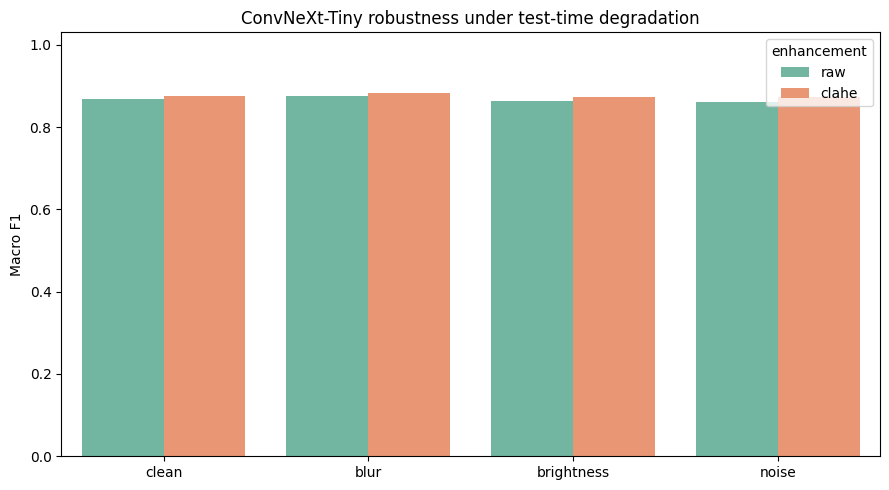

In [ ]:
# ============================================================
# Robustness evaluation without retraining
# ============================================================
robustness_rows = []
degradation_modes = ["clean", "blur", "brightness", "noise"]
robustness_configs = [
    ("convnext_tiny__raw", "raw"),
    (best_enhanced_id, best_enhancement),
]
robustness_configs = list(dict.fromkeys(robustness_configs))

for experiment_id, enhancement in robustness_configs:
    model = build_model("convnext_tiny", use_pretrained=False).to(DEVICE)
    model.load_state_dict(torch.load(
        experiment_checkpoints[experiment_id], map_location=DEVICE
    ))
    for degradation in degradation_modes:
        _, _, degraded_test_loader = make_loaders(enhancement, degradation=degradation)
        y_true, probabilities, _ = predict_loader(model, degraded_test_loader)
        metrics = metric_bundle(y_true, probabilities)
        robustness_rows.append({
            "experiment_id": experiment_id,
            "enhancement": enhancement,
            "degradation": degradation,
            **metrics,
        })
    del model
    gc.collect()
    torch.cuda.empty_cache()

robustness_table = pd.DataFrame(robustness_rows)
clean_f1_map = (
    robustness_table[robustness_table["degradation"] == "clean"]
    .set_index("experiment_id")["macro_f1"].to_dict()
)
robustness_table["macro_f1_drop"] = robustness_table.apply(
    lambda row: clean_f1_map[row["experiment_id"]] - row["macro_f1"], axis=1
)
display(robustness_table.round(4))
robustness_table.to_csv(RESULTS_DIR / "robustness_results.csv", index=False)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=robustness_table, x="degradation", y="macro_f1",
    hue="enhancement", palette="Set2"
)
plt.ylim(0, 1.03)
plt.title("ConvNeXt-Tiny robustness under test-time degradation")
plt.xlabel("")
plt.ylabel("Macro F1")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "robustness_comparison.png", dpi=240, bbox_inches="tight")
plt.show()


## 16. Computational Efficiency

Parameter count, checkpoint size, and GPU inference latency are reported for all 12 trained
models. Ensemble inference cost can be estimated as the sum of its three selected component
latencies; ensemble arithmetic itself is negligible.


In [ ]:
# ============================================================
# Parameter count, checkpoint size, and inference latency
# ============================================================
efficiency_rows = []
_, _, efficiency_test_loader = make_loaders("raw")
sample_batch = next(iter(efficiency_test_loader))[0][: min(BATCH_SIZE, 32)].to(DEVICE)

for experiment_id in single_view_results["experiment_id"]:
    model_name = experiment_id.split("__")[0]
    model = build_model(model_name, use_pretrained=False).to(DEVICE)
    model.load_state_dict(torch.load(
        experiment_checkpoints[experiment_id], map_location=DEVICE
    ))
    model.eval()
    for _ in range(10):
        with torch.no_grad():
            _ = model(sample_batch)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()
    repetitions = 30
    for _ in range(repetitions):
        with torch.no_grad():
            _ = model(sample_batch)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start
    latency_ms = elapsed * 1000 / (repetitions * len(sample_batch))
    parameter_count = sum(parameter.numel() for parameter in model.parameters())
    checkpoint_mb = Path(experiment_checkpoints[experiment_id]).stat().st_size / (1024 ** 2)
    training_seconds = single_view_results.loc[
        single_view_results["experiment_id"] == experiment_id, "training_seconds"
    ].iloc[0]
    efficiency_rows.append({
        "experiment_id": experiment_id,
        "parameters_million": parameter_count / 1e6,
        "checkpoint_mb": checkpoint_mb,
        "inference_ms_per_image": latency_ms,
        "training_minutes": training_seconds / 60,
    })
    del model
    gc.collect()
    torch.cuda.empty_cache()

efficiency_table = pd.DataFrame(efficiency_rows)
ensemble_latency = efficiency_table[
    efficiency_table["experiment_id"].isin(selected_ids)
]["inference_ms_per_image"].sum()
efficiency_table = pd.concat([
    efficiency_table,
    pd.DataFrame([{
        "experiment_id": "three_model_ensemble",
        "parameters_million": efficiency_table[
            efficiency_table["experiment_id"].isin(selected_ids)
        ]["parameters_million"].sum(),
        "checkpoint_mb": efficiency_table[
            efficiency_table["experiment_id"].isin(selected_ids)
        ]["checkpoint_mb"].sum(),
        "inference_ms_per_image": ensemble_latency,
        "training_minutes": 0.0,
    }])
], ignore_index=True)

del efficiency_test_loader
display(efficiency_table.round(3))
efficiency_table.to_csv(RESULTS_DIR / "model_efficiency.csv", index=False)


,experiment_id,parameters_million,checkpoint_mb,inference_ms_per_image,training_minutes
0,convnext_tiny__clahe,27.823,106.203,4.076,0.000
1,convnext_tiny__gamma,27.823,106.203,4.117,12.405
2,convnext_tiny__raw,27.823,106.203,4.168,9.030
3,convnext_tiny__sharpen,27.823,106.203,4.208,6.566
4,efficientnet_b0__clahe,4.013,15.597,1.170,0.000
5,efficientnet_b0__gamma,4.013,15.597,1.170,11.727
6,efficientnet_b0__raw,4.013,15.596,1.170,8.214
7,efficientnet_b0__sharpen,4.013,15.598,1.170,9.240
8,resnet50__clahe,23.516,90.013,3.024,14.321
9,resnet50__gamma,23.516,90.013,3.044,7.932


## 17. Error Analysis

Misclassified test images are summarized for the configuration selected for ROC and
precision-recall analysis. This identifies systematic class confusion without changing
the reported model performance.


In [ ]:
# ============================================================
# Misclassification summary for the best model
# ============================================================
error_df = pd.DataFrame({
    "path": best_data["paths"],
    "true_idx": best_data["y_true"],
    "pred_idx": best_data["probabilities"].argmax(1),
    "confidence": best_data["probabilities"].max(axis=1),
})
error_df["true_class"] = error_df["true_idx"].map(dict(enumerate(CLASS_NAMES)))
error_df["predicted_class"] = error_df["pred_idx"].map(dict(enumerate(CLASS_NAMES)))
error_df = error_df[error_df["true_idx"] != error_df["pred_idx"]].copy()

error_pairs = (
    error_df.groupby(["true_class", "predicted_class"])
    .agg(errors=("path", "size"), mean_confidence=("confidence", "mean"))
    .reset_index()
    .sort_values("errors", ascending=False)
)
display(error_pairs.round(4))
display(error_df.sort_values("confidence", ascending=False).head(20))
error_pairs.to_csv(RESULTS_DIR / "misclassification_pairs.csv", index=False)
error_df.to_csv(RESULTS_DIR / "misclassified_images.csv", index=False)

if len(error_pairs):
    top_error = error_pairs.iloc[0]
    interpretation = (
        f"The most frequent error direction was **{top_error['true_class']} -> "
        f"{top_error['predicted_class']}**, occurring **{int(top_error['errors'])}** times."
    )
else:
    interpretation = "No test-set misclassification was observed; external validation remains necessary."
display(Markdown(f"**Research finding.** {interpretation}"))


,true_class,predicted_class,errors,mean_confidence
3,GERD Normal,GERD,18,0.7148
0,GERD,GERD Normal,16,0.7667
8,Polyp Normal,GERD Normal,6,0.7010
9,Polyp Normal,Polyp,6,0.6397
6,Polyp,Polyp Normal,6,0.8104
5,Polyp,GERD Normal,4,0.8932
4,GERD Normal,Polyp Normal,3,0.5191
2,GERD,Polyp Normal,3,0.7051
7,Polyp Normal,GERD,2,0.6194
1,GERD,Polyp,1,0.8672


,path,true_idx,pred_idx,confidence,true_class,predicted_class
106,/content/gerd_polyp_original/Gerd Normal/norma...,1,0,0.972906,GERD Normal,GERD
568,/content/gerd_polyp_original/Gerd Normal/norma...,1,0,0.960655,GERD Normal,GERD
405,/content/gerd_polyp_original/Gerd Normal/norma...,1,0,0.956857,GERD Normal,GERD
383,/content/gerd_polyp_original/Gerd Normal/norma...,1,0,0.946035,GERD Normal,GERD
119,/content/gerd_polyp_original/Gerd/gerd image ...,0,1,0.945608,GERD,GERD Normal
56,/content/gerd_polyp_original/Gerd Normal/norma...,1,0,0.944925,GERD Normal,GERD
420,/content/gerd_polyp_original/Gerd Normal/norma...,1,0,0.944658,GERD Normal,GERD
295,/content/gerd_polyp_original/Polyp/polyp image...,2,1,0.943187,Polyp,GERD Normal
328,/content/gerd_polyp_original/Gerd/gerd image ...,0,1,0.931654,GERD,GERD Normal
213,/content/gerd_polyp_original/Polyp/polyp image...,2,1,0.931640,Polyp,GERD Normal


**Research finding.** The most frequent error direction was **GERD Normal -> GERD**, occurring **18** times.

## 18. Manuscript-Ready Summary Tables and Figures

The primary publication table contains the balanced 12-model multi-enhancement experiment.
The ensemble is shown separately so that a weaker ensemble cannot obscure or
reframe the main finding.


### Primary multi-enhancement experiment

,experiment_id,model,configuration,enhancement,configuration_type,best_val_macro_f1,best_epoch,training_seconds,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,log_loss,roc_auc_ovr_macro,pr_auc_macro
0,convnext_tiny__clahe,convnext_tiny,clahe,clahe,single_view,0.8877,12,0.0000,0.8735,0.8751,0.8758,0.8751,0.8752,0.8739,0.3730,0.9740,0.9350
1,convnext_tiny__raw,convnext_tiny,raw,raw,single_view,0.8755,13,541.7972,0.8669,0.8662,0.8697,0.8662,0.8677,0.8671,0.4172,0.9640,0.9055
2,convnext_tiny__sharpen,convnext_tiny,sharpen,sharpen,single_view,0.8721,6,393.9349,0.8652,0.8623,0.8697,0.8623,0.8653,0.8653,0.3894,0.9710,0.9267
3,efficientnet_b0__gamma,efficientnet_b0,gamma,gamma,single_view,0.8574,15,703.6495,0.8652,0.8635,0.8664,0.8635,0.8648,0.8653,0.4102,0.9636,0.9185
4,resnet50__clahe,resnet50,clahe,clahe,single_view,0.8577,11,859.2892,0.8619,0.8610,0.8653,0.8610,0.8628,0.8621,0.4405,0.9583,0.9065
5,resnet50__sharpen,resnet50,sharpen,sharpen,single_view,0.8732,11,0.0000,0.8619,0.8598,0.8661,0.8598,0.8622,0.8619,0.4138,0.9627,0.9141
6,convnext_tiny__gamma,convnext_tiny,gamma,gamma,single_view,0.8833,11,744.3117,0.8602,0.8602,0.8645,0.8602,0.8618,0.8608,0.4112,0.9697,0.9241
7,efficientnet_b0__raw,efficientnet_b0,raw,raw,single_view,0.8692,15,492.8634,0.8586,0.8561,0.8627,0.8561,0.8587,0.8587,0.4173,0.9623,0.9116
8,resnet50__raw,resnet50,raw,raw,single_view,0.8716,14,492.5835,0.8552,0.8524,0.8586,0.8524,0.8549,0.8549,0.4230,0.9661,0.9206
9,efficientnet_b0__sharpen,efficientnet_b0,sharpen,sharpen,single_view,0.8703,15,554.3884,0.8552,0.8528,0.8578,0.8528,0.8548,0.8554,0.4331,0.9606,0.9036


,Raw,Sharpen,CLAHE,Gamma
model,,,,
resnet50,0.854900,0.862200,0.862800,0.844200
efficientnet_b0,0.858700,0.854800,0.843500,0.864800
convnext_tiny,0.867700,0.865300,0.875200,0.861800


### Proposed validation-weighted ensemble

,configuration,role,macro_f1,delta_vs_selected_individual
0,convnext_tiny__clahe,validation-selected individual comparator,0.8752,0.0000
1,multi_model__validation_weighted_soft_voting,proposed validation-weighted ensemble,0.8935,0.0183


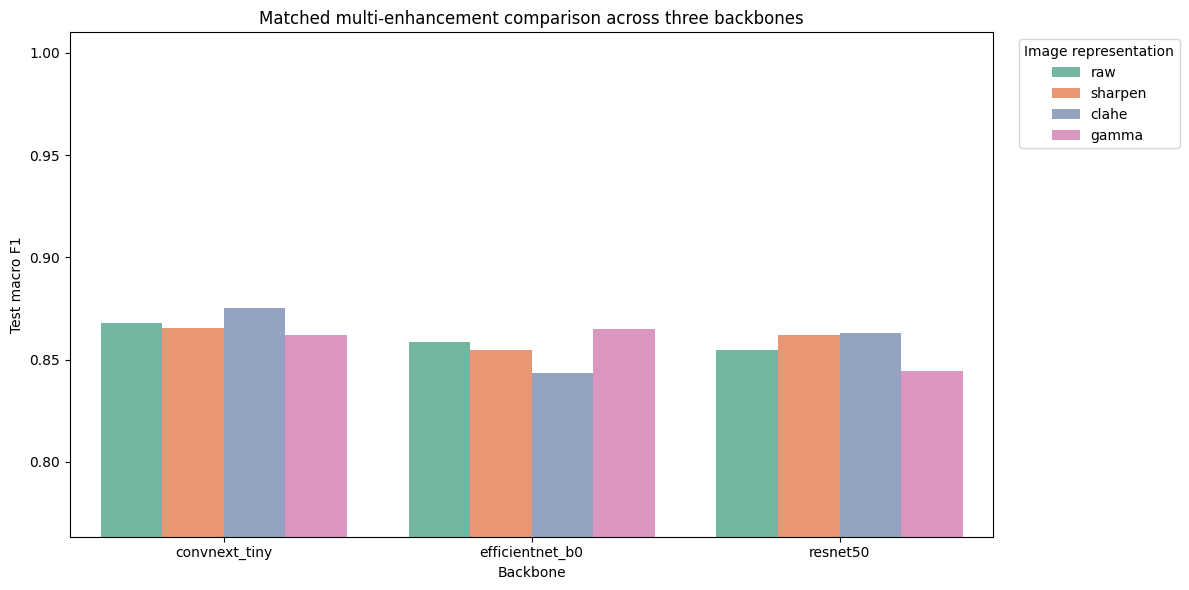

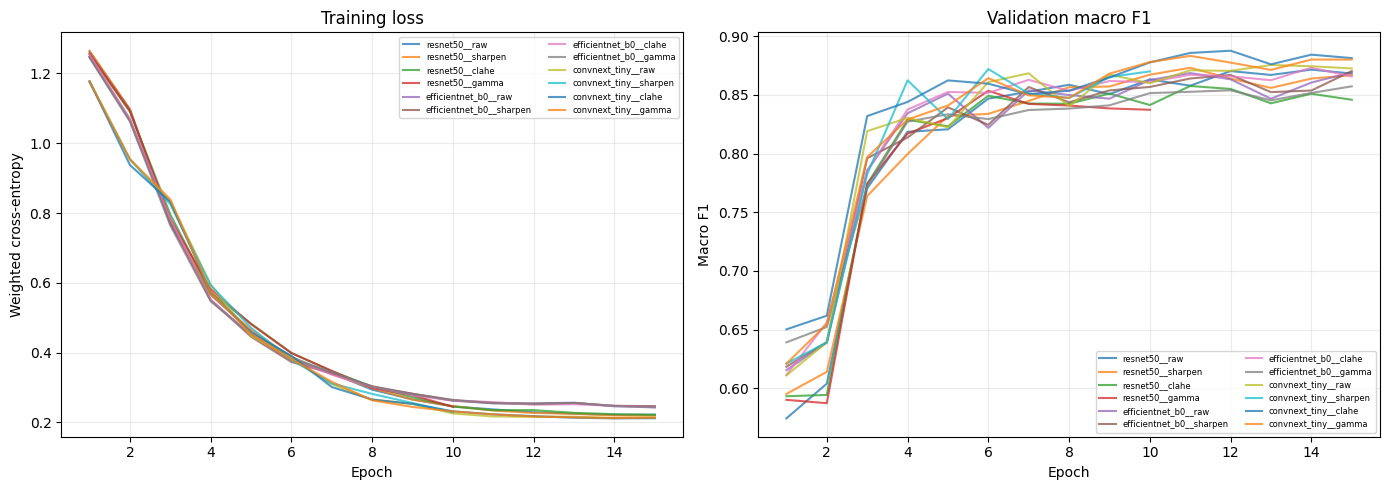

In [ ]:
# ============================================================
# Manuscript-ready primary and ensemble results
# ============================================================
manuscript_main = single_view_results.copy().sort_values(
    "macro_f1", ascending=False
).reset_index(drop=True)
manuscript_main.to_csv(RESULTS_DIR / "manuscript_primary_results.csv", index=False)
display(Markdown("### Primary multi-enhancement experiment"))
display(manuscript_main.round(4))

publication_table = single_view_results.pivot(
    index="model", columns="configuration", values="macro_f1"
).reindex(index=BACKBONE_MODELS, columns=SINGLE_VIEW_MODES)
publication_table.columns = ["Raw", "Sharpen", "CLAHE", "Gamma"]
display(publication_table.round(4).style.highlight_max(axis=1, color="#c6efce"))
publication_table.to_csv(RESULTS_DIR / "publication_macro_f1_table.csv")

display(Markdown("### Proposed validation-weighted ensemble"))
display(proposed_comparison.round(4))

plt.figure(figsize=(12, 6))
sns.barplot(
    data=single_view_results, x="model", y="macro_f1", hue="configuration",
    hue_order=SINGLE_VIEW_MODES, palette="Set2"
)
plt.ylim(max(0, single_view_results["macro_f1"].min() - 0.08), 1.01)
plt.title("Matched multi-enhancement comparison across three backbones")
plt.xlabel("Backbone")
plt.ylabel("Test macro F1")
plt.legend(title="Image representation", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "balanced_12_configuration_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for experiment_id, history in experiment_histories.items():
    axes[0].plot(history["epoch"], history["train_loss"], alpha=0.75, label=experiment_id)
    axes[1].plot(history["epoch"], history["val_macro_f1"], alpha=0.75, label=experiment_id)
axes[0].set(title="Training loss", xlabel="Epoch", ylabel="Weighted cross-entropy")
axes[1].set(title="Validation macro F1", xlabel="Epoch", ylabel="Macro F1")
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend(fontsize=6, ncol=2)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "learning_curves.png", dpi=240, bbox_inches="tight")
plt.show()


## 19. Final Research Findings and Limitations

The final proposed configuration is the validation-weighted multi-enhancement ensemble.
No alternative ensemble rule is evaluated or reported.


In [ ]:
# ============================================================
# Dynamic findings and publication checklist
# ============================================================
best_primary = manuscript_main.iloc[0]
best_raw = single_view_results[
    single_view_results["configuration"] == "raw"
].sort_values("macro_f1", ascending=False).iloc[0]

proposed_data = experiment_predictions[weighted_id]
proposed_metrics = metric_bundle(
    proposed_data["y_true"], proposed_data["probabilities"]
)
final_proposed_id = weighted_id

findings_table = pd.DataFrame({
    "Finding": [
        "Best raw-image baseline",
        "Best individual configuration",
        "Final proposed configuration",
        "Final validation macro F1",
        "Final test accuracy",
        "Final test macro F1",
        "Final test balanced accuracy",
        "Final test ROC-AUC",
        "Final test PR-AUC",
        "Final test log loss",
        "Macro-F1 gain over best raw baseline",
        "Balanced individual models trained",
    ],
    "Result": [
        f"{best_raw['experiment_id']} (macro F1={best_raw['macro_f1']:.4f})",
        f"{best_primary['experiment_id']} (macro F1={best_primary['macro_f1']:.4f})",
        final_proposed_id,
        f"{weighted_val_metrics['macro_f1']:.4f}",
        f"{proposed_metrics['accuracy']:.4f}",
        f"{proposed_metrics['macro_f1']:.4f}",
        f"{proposed_metrics['balanced_accuracy']:.4f}",
        f"{proposed_metrics['roc_auc_ovr_macro']:.4f}",
        f"{proposed_metrics['pr_auc_macro']:.4f}",
        f"{proposed_metrics['log_loss']:.4f}",
        f"{proposed_metrics['macro_f1'] - best_raw['macro_f1']:.4f}",
        str(len(single_view_results)),
    ],
})
display(findings_table)
findings_table.to_csv(
    RESULTS_DIR / "final_research_findings.csv", index=False
)

limitations_table = pd.DataFrame({
    "Limitation": ["Single-source dataset"],
    "Implication": [
        "External performance may differ across hospitals, populations, and endoscope systems."
    ],
})
display(limitations_table)
limitations_table.to_csv(RESULTS_DIR / "limitations.csv", index=False)

checklist = pd.DataFrame({
    "Manuscript requirement": [
        "FAST_RUN disabled",
        "Primary-image count verified",
        "No exact-image split overlap",
        "Twelve balanced individual models",
        "Proposed validation-weighted ensemble evaluated",
        "Weights selected on validation only",
        "Bootstrap intervals reported",
        "Prespecified paired test reported",
    ],
    "Status": [
        not FAST_RUN,
        plausible_primary_count(len(primary_manifest)),
        True,
        len(single_view_results) == 12,
        weighted_id in experiment_predictions,
        not weight_search_table.empty,
        not ci_table.empty,
        len(mcnemar_table) == 1,
    ],
})
display(checklist)
checklist.to_csv(
    RESULTS_DIR / "publication_checklist.csv", index=False
)


,Finding,Result
0,Best raw-image baseline,convnext_tiny__raw (macro F1=0.8677)
1,Best individual configuration,convnext_tiny__clahe (macro F1=0.8752)
2,Final proposed configuration,multi_model__validation_weighted_soft_voting
3,Final validation macro F1,0.9039
4,Final test accuracy,0.8918
5,Final test macro F1,0.8935
6,Final test balanced accuracy,0.8924
7,Final test ROC-AUC,0.9785
8,Final test PR-AUC,0.9458
9,Final test log loss,0.3373


,Limitation,Implication
0,Single-source dataset,External performance may differ across hospita...


,Manuscript requirement,Status
0,FAST_RUN disabled,True
1,Primary-image count verified,True
2,No exact-image split overlap,True
3,Twelve balanced individual models,True
4,Proposed validation-weighted ensemble evaluated,True
5,Weights selected on validation only,True
6,Bootstrap intervals reported,True
7,Prespecified paired test reported,True


## 20. Save All Outputs

CSV tables, figures, retained model checkpoints, and ZIP archives are saved persistently
under `MyDrive/GERD_POLYP_COLAB`. They remain available if the Colab runtime disconnects.


In [ ]:
# ============================================================
# Save final metadata and compact results ZIP
# ============================================================
run_metadata = {
    "timestamp_utc": pd.Timestamp.utcnow().isoformat(),
    "fast_run": FAST_RUN,
    "seed": SEED,
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "effective_epochs": EFFECTIVE_EPOCHS,
    "dataset_zip": DRIVE_ZIP_PATH,
    "dataset_root": str(DATASET_ROOT),
    "primary_image_count": len(primary_manifest),
    "train_count": len(train_df),
    "validation_count": len(val_df),
    "test_count": len(test_df),
    "selected_components": selected_ids,
    "proposed_experiment": weighted_id,
    "proposed_test_accuracy": proposed_metrics["accuracy"],
    "proposed_test_macro_f1": proposed_metrics["macro_f1"],
    "device": str(DEVICE),
    "pytorch_version": torch.__version__,
}
with open(RESULTS_DIR / "run_metadata.json", "w") as stream:
    json.dump(run_metadata, stream, indent=2)

retained_ids = {selected_single_id, *selected_ids}
if not KEEP_ALL_CHECKPOINTS:
    for experiment_id, checkpoint in experiment_checkpoints.items():
        if experiment_id not in retained_ids and Path(checkpoint).exists():
            Path(checkpoint).unlink()

import zipfile
archive_path = WORK_ROOT / "GERD_FINAL_224_RESULTS.zip"
with zipfile.ZipFile(
    archive_path, "w", compression=zipfile.ZIP_DEFLATED
) as archive:
    for folder in [RESULTS_DIR, FIGURES_DIR]:
        for path in folder.rglob("*"):
            if path.is_file():
                archive.write(path, path.relative_to(WORK_ROOT))

display(Markdown(
    f"**Completed.** Results ZIP: `{archive_path}`  \n"
    f"Proposed method: **{final_proposed_id}**  \n"
    f"Accuracy / macro F1: "
    f"**{proposed_metrics['accuracy']:.2%} / {proposed_metrics['macro_f1']:.2%}**  \n"
    f"Retained checkpoints: **{len(list(MODELS_DIR.glob('*.pt')))}**"
))


**Completed.** Results ZIP: `/content/drive/MyDrive/GERD_POLYP_COLAB/GERD_FINAL_224_RESULTS.zip`  
Proposed method: **multi_model__validation_weighted_soft_voting**  
Accuracy / macro F1: **89.18% / 89.35%**  
Retained checkpoints: **3**

## Dataset Citation

- Bitto, A. K., Bijoy, M. H. I., Shakil, K. H., et al. (2025).
  *GastroEndoNet: Comprehensive endoscopy image dataset for GERD and polyp detection*.
  Data in Brief, 60, 111572. https://doi.org/10.1016/j.dib.2025.111572
- GastroEndoNet v3 data record: https://doi.org/10.17632/ffyn828yf4.3
- Kaggle mirror used by this notebook:
  https://www.kaggle.com/datasets/suvalakshmissbalaji/endoscopy-image-dataset-for-gerd-and-polyp-detection


In [ ]:
import shutil

tables_archive = shutil.make_archive(
    str(WORK_ROOT / "GERD_TABLES"),
    "zip",
    str(RESULTS_DIR),
)
figures_archive = shutil.make_archive(
    str(WORK_ROOT / "GERD_FIGURES"),
    "zip",
    str(FIGURES_DIR),
)

print("Persistent Colab outputs:")
print(tables_archive)
print(figures_archive)
print(WORK_ROOT / "GERD_FINAL_224_RESULTS.zip")


Persistent Colab outputs:
/content/drive/MyDrive/GERD_POLYP_COLAB/GERD_TABLES.zip
/content/drive/MyDrive/GERD_POLYP_COLAB/GERD_FIGURES.zip
/content/drive/MyDrive/GERD_POLYP_COLAB/GERD_FINAL_224_RESULTS.zip
